<a href="https://colab.research.google.com/github/hmjisan/FW-PER/blob/main/FW_PER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Ensure we are using the T4 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ==========================================
# 1. Variational Autoencoder (VAE)
# ==========================================
class StateVAE(nn.Module):
    def __init__(self, input_dim=64, latent_dim=32):
        super(StateVAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)

        # Decoder
        self.fc3 = nn.Linear(latent_dim, 128)
        self.fc4 = nn.Linear(128, input_dim)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar, z

# ==========================================
# 2. Latent Density Estimator (k-NN)
# ==========================================
class LatentDensityEstimator:
    def __init__(self, k=5, eta=1e-5):
        self.k = k
        self.eta = eta # Smoothing constant

    def compute_phi(self, z_batch, z_buffer=None):
        """
        Calculates the semantic rarity score (phi) for a batch of latent states.
        Keeps operations on the GPU for T4 optimization.
        """
        # If no historical buffer is provided, estimate density within the batch itself
        if z_buffer is None:
            z_buffer = z_batch

        # Compute pairwise Euclidean distances between batch and buffer
        # Using torch.cdist for highly optimized GPU distance calculations
        distances = torch.cdist(z_batch, z_buffer, p=2.0)

        # Get the distances to the k-nearest neighbors
        # We use k+1 and slice [:, 1:] to ignore the state's distance to itself (which is 0)
        topk_dist, _ = torch.topk(distances, self.k + 1, largest=False, dim=1)
        knn_dist = topk_dist[:, 1:]

        # Density (rho) is inversely proportional to the mean distance of the k-NN
        # Larger distance -> lower density
        rho = 1.0 / (knn_dist.mean(dim=1) + self.eta)

        # Compute Log-Scaled Phi to mitigate importance sampling variance
        phi = torch.log(1.0 + (1.0 / (rho + self.eta)))

        return phi

# ==========================================
# 3. FW-PER Priority Simulation
# ==========================================
def simulate_fw_per():
    # Hyperparameters
    batch_size = 256
    obs_dim = 64      # e.g., kinematic vector from Highway-env
    latent_dim = 16   # Kept small to avoid curse of dimensionality
    epsilon = 1e-3    # Small constant for numerical stability

    # Initialize models on T4 GPU
    vae = StateVAE(input_dim=obs_dim, latent_dim=latent_dim).to(device)
    density_estimator = LatentDensityEstimator(k=5)

    # Simulate a batch of states and corresponding TD-errors
    # Imagine 90% of these are common "safe driving" states, 10% are rare hazards
    states = torch.randn(batch_size, obs_dim).to(device)

    # Simulate TD-errors (mathematical surprise)
    td_errors = torch.rand(batch_size).to(device)

    # --- The FW-PER Process ---
    vae.eval() # Set to evaluation mode for inference
    with torch.no_grad():
        # 1. Map states to latent space
        _, _, _, z = vae(states)

        # 2. Compute Semantic Rarity (Phi)
        phi_scores = density_estimator.compute_phi(z)

        # 3. Calculate Final Multiplicative Priority (p_i = (|delta_i| + eps) * phi)
        priorities = (torch.abs(td_errors) + epsilon) * phi_scores

    print(f"Mean TD-Error: {td_errors.mean().item():.4f}")
    print(f"Mean Semantic Rarity (Phi): {phi_scores.mean().item():.4f}")
    print(f"Mean Final FW-PER Priority: {priorities.mean().item():.4f}")
    print("\nShape check passed! The framework successfully mapped 64D states -> 16D latent vectors -> Density priorities.")

if __name__ == "__main__":
    simulate_fw_per()

Using device: cuda
Mean TD-Error: 0.4968
Mean Semantic Rarity (Phi): 1.5567
Mean Final FW-PER Priority: 0.7745

Shape check passed! The framework successfully mapped 64D states -> 16D latent vectors -> Density priorities.


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. Keep the StateVAE and LatentDensityEstimator classes from before ---
# (Assume the exact same class definitions for StateVAE and LatentDensityEstimator here)
class StateVAE(nn.Module):
    def __init__(self, input_dim=64, latent_dim=16):
        super(StateVAE, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)
        self.fc3 = nn.Linear(latent_dim, 64)
        self.fc4 = nn.Linear(64, input_dim)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar, z

class LatentDensityEstimator:
    def __init__(self, k=10, eta=1e-5):
        self.k = k
        self.eta = eta
    def compute_phi(self, z_batch, z_buffer=None):
        if z_buffer is None: z_buffer = z_batch
        distances = torch.cdist(z_batch, z_buffer, p=2.0)
        topk_dist, _ = torch.topk(distances, self.k + 1, largest=False, dim=1)
        knn_dist = topk_dist[:, 1:]
        rho = 1.0 / (knn_dist.mean(dim=1) + self.eta)
        phi = torch.log(1.0 + (1.0 / (rho + self.eta)))
        return phi

# --- 2. The Core Experiment ---
def run_noisy_tv_ablation():
    N_normal = 1000
    N_noisy = 300
    N_rare = 50

    # 1. Normal States: tight cluster (Common)
    states_normal = torch.randn(N_normal, 64).to(device) * 0.1
    # 2. Noisy TV: massive, uniform random noise (Aleatoric)
    states_noisy = (torch.rand(N_noisy, 64).to(device) - 0.5) * 10.0
    # 3. Rare Hazard: structured outlier (Epistemic)
    states_rare = torch.randn(N_rare, 64).to(device) * 0.1 + 5.0

    all_states = torch.cat([states_normal, states_noisy, states_rare])

    # Simulate TD-Errors (Standard PER mechanism)
    # Note: Noisy TV has the highest TD error because it is unpredictable!
    td_normal = torch.rand(N_normal).to(device) * 0.2
    td_noisy = torch.rand(N_noisy).to(device) * 1.0 + 1.5
    td_rare = torch.rand(N_rare).to(device) * 0.5 + 1.2
    td_all = torch.cat([td_normal, td_noisy, td_rare])

    # Initialize Beta-VAE
    vae = StateVAE(input_dim=64, latent_dim=16).to(device)
    optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

    # BETA is the secret sauce: A high Beta forces unlearnable noise to collapse into the prior
    beta = 8.0

    print("Training Beta-VAE to learn the manifold... This will take ~5 seconds on T4.")
    for epoch in range(1000):
        optimizer.zero_grad()
        recon, mu, logvar, z = vae(all_states)
        recon_loss = F.mse_loss(recon, all_states, reduction='mean')
        kld_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + beta * kld_loss
        loss.backward()
        optimizer.step()

    # Evaluate the Framework
    vae.eval()
    with torch.no_grad():
        _, _, _, z_all = vae(all_states)
        density_estimator = LatentDensityEstimator(k=10)

        # Calculate Semantic Rarity
        phi_all = density_estimator.compute_phi(z_all)

        # Final FW-PER Priority = TD-Error * Phi
        fw_per_priority = td_all * phi_all

        print("\n" + "="*50)
        print("RESULTS FOR JOURNAL ABLATION STUDY")
        print("="*50)

        print("\n1. Standard PER Priority (TD-Error Only):")
        print(f"   Normal Driving: {td_normal.mean().item():.3f}")
        print(f"   Rare Hazards:   {td_rare.mean().item():.3f}")
        print(f"   Noisy TV:       {td_noisy.mean().item():.3f}  <-- Agent gets permanently stuck sampling this!")

        print("\n2. FW-PER Semantic Rarity Filter (Phi):")
        print(f"   Normal Driving: {phi_all[:N_normal].mean().item():.3f}")
        print(f"   Noisy TV:       {phi_all[N_normal:N_normal+N_noisy].mean().item():.3f}  <-- Beta-VAE collapsed the noise; it is no longer 'rare'")
        print(f"   Rare Hazards:   {phi_all[-N_rare:].mean().item():.3f}  <-- Identified as truly rare and structured!")

if __name__ == "__main__":
    run_noisy_tv_ablation()

Training Beta-VAE to learn the manifold... This will take ~5 seconds on T4.

RESULTS FOR JOURNAL ABLATION STUDY

1. Standard PER Priority (TD-Error Only):
   Normal Driving: 0.100
   Rare Hazards:   1.487
   Noisy TV:       2.007  <-- Agent gets permanently stuck sampling this!

2. FW-PER Semantic Rarity Filter (Phi):
   Normal Driving: 1.448
   Noisy TV:       1.447  <-- Beta-VAE collapsed the noise; it is no longer 'rare'
   Rare Hazards:   1.597  <-- Identified as truly rare and structured!


In [ ]:
import numpy as np
import torch

class FeatureWeightedReplayBuffer:
    def __init__(self, capacity, obs_dim, latent_dim, alpha=0.6, epsilon=1e-3):
        self.capacity = capacity
        self.alpha = alpha       # Controls how much prioritization is used
        self.epsilon = epsilon   # Prevents zero probability [cite: 23]
        self.ptr = 0
        self.size = 0

        # Standard RL Transition Storage
        self.states = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, 1), dtype=np.int64)
        self.rewards = np.zeros((capacity, 1), dtype=np.float32)
        self.next_states = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.dones = np.zeros((capacity, 1), dtype=np.float32)

        # FW-PER Specific Storage
        self.latents = np.zeros((capacity, latent_dim), dtype=np.float32)
        self.td_errors = np.zeros(capacity, dtype=np.float32)
        self.phi_scores = np.ones(capacity, dtype=np.float32) # Init to 1.0 (Neutral)
        self.priorities = np.zeros(capacity, dtype=np.float32)

    def add(self, state, action, reward, next_state, done, latent_z):
        """Stores a new transition. It inherits the MAX priority initially to ensure it gets sampled at least once."""
        max_prio = self.priorities.max() if self.size > 0 else 1.0

        self.states[self.ptr] = state
        self.actions[self.ptr] = action
        self.rewards[self.ptr] = reward
        self.next_states[self.ptr] = next_state
        self.dones[self.ptr] = done
        self.latents[self.ptr] = latent_z

        self.priorities[self.ptr] = max_prio # Will be corrected after first backward pass

        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def update_priorities(self, batch_indices, batch_td_errors):
        """Called by the DQN after a training step to update the mathematical surprise."""
        for i, idx in enumerate(batch_indices):
            self.td_errors[idx] = abs(batch_td_errors[i])
            # The FW-PER Core Equation
            self.priorities[idx] = (self.td_errors[idx] + self.epsilon) * self.phi_scores[idx]

    def update_semantic_rarity(self, density_estimator):
        """
        Called periodically (e.g., every 1000 steps) to update phi.
        Doing this every step would cause a 'drifting' latent space and crash the Colab instance[cite: 124, 125].
        """
        if self.size < 100: return # Wait for enough data

        # Convert valid stored latents to tensor
        z_buffer = torch.FloatTensor(self.latents[:self.size]).to(device)

        # Compute phi for the entire current memory
        with torch.no_grad():
            new_phis = density_estimator.compute_phi(z_buffer, z_buffer).cpu().numpy()

        self.phi_scores[:self.size] = new_phis

        # Recalculate all priorities with the new semantic weights
        self.priorities[:self.size] = (self.td_errors[:self.size] + self.epsilon) * self.phi_scores[:self.size]

    def sample(self, batch_size, beta=0.4):
        """Samples a batch based on the FW-PER priorities."""
        if self.size == 0: return None

        # Calculate sampling probabilities: P(i) = p_i^alpha / sum(p_k^alpha) [cite: 25]
        prios = self.priorities[:self.size]
        probs = prios ** self.alpha
        probs /= probs.sum()

        # Sample indices
        indices = np.random.choice(self.size, batch_size, p=probs)

        # Calculate Importance Sampling (IS) weights to correct for bias
        # IS = (1/N * 1/P(i))^beta
        total = self.size
        weights = (total * probs[indices]) ** (-beta)
        weights /= weights.max() # Normalize for stability

        batch = (
            torch.FloatTensor(self.states[indices]).to(device),
            torch.LongTensor(self.actions[indices]).to(device),
            torch.FloatTensor(self.rewards[indices]).to(device),
            torch.FloatTensor(self.next_states[indices]).to(device),
            torch.FloatTensor(self.dones[indices]).to(device),
            torch.FloatTensor(weights).to(device),
            indices
        )
        return batch

In [ ]:
# --- Test Script to Verify the FW-PER Buffer ---
def test_buffer():
    print("Initializing FW-PER Buffer...")
    # 1. Create the buffer (Capacity 1000, 64D obs, 16D latent)
    buffer = FeatureWeightedReplayBuffer(capacity=1000, obs_dim=64, latent_dim=16)

    # 2. Re-initialize our Density Estimator from the previous step
    density_estimator = LatentDensityEstimator(k=5)

    print("Adding 200 dummy transitions to memory...")
    # 3. Add fake data to the buffer
    for _ in range(200):
        state = np.random.randn(64).astype(np.float32)
        action = np.random.randint(0, 4)
        reward = np.random.rand()
        next_state = np.random.randn(64).astype(np.float32)
        done = False
        latent_z = np.random.randn(16).astype(np.float32) # Fake latent vector

        # Add to buffer
        buffer.add(state, action, reward, next_state, done, latent_z)

    print(f"Buffer currently holds {buffer.size} transitions.")

    # 4. Simulate a DQN updating the TD-errors
    fake_indices = np.arange(50)
    fake_td_errors = np.random.rand(50).astype(np.float32) * 2.0
    buffer.update_priorities(fake_indices, fake_td_errors)

    # 5. Update Semantic Rarity (The "Slow Loop")
    print("Calculating Semantic Rarity (Phi) for the entire buffer...")
    buffer.update_semantic_rarity(density_estimator)

    # 6. Sample a batch!
    print("Sampling a batch of 32 transitions based on FW-PER priorities...")
    batch = buffer.sample(batch_size=32)

    states, actions, rewards, next_states, dones, weights, indices = batch

    print("\n" + "="*40)
    print("BUFFER TEST SUCCESSFUL!")
    print("="*40)
    print(f"Sampled States Shape: {states.shape} (Should be 32, 64)")
    print(f"Importance Sampling Weights Shape: {weights.shape} (Should be 32)")
    print(f"Sampled Indices: {indices[:5]}...") # Just print the first 5

test_buffer()

Initializing FW-PER Buffer...
Adding 200 dummy transitions to memory...
Buffer currently holds 200 transitions.
Calculating Semantic Rarity (Phi) for the entire buffer...
Sampling a batch of 32 transitions based on FW-PER priorities...

BUFFER TEST SUCCESSFUL!
Sampled States Shape: torch.Size([32, 64]) (Should be 32, 64)
Importance Sampling Weights Shape: torch.Size([32]) (Should be 32)
Sampled Indices: [38  6 20  5 35]...


In [ ]:
!pip install gymnasium highway-env

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.7/107.7 kB 5.6 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym
import highway_env
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 1. The Q-Network ---
class QNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(obs_dim, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

# --- 2. The FW-PER Agent ---
class FWPER_Agent:
    def __init__(self, obs_dim, action_dim):
        self.action_dim = action_dim
        self.obs_dim = obs_dim

        # Double DQN Networks
        self.q_online = QNetwork(obs_dim, action_dim).to(device)
        self.q_target = QNetwork(obs_dim, action_dim).to(device)
        self.q_target.load_state_dict(self.q_online.state_dict())
        self.q_optimizer = torch.optim.Adam(self.q_online.parameters(), lr=5e-4)

        # FW-PER Memory & Semantic Gatekeepers
        self.memory = FeatureWeightedReplayBuffer(capacity=10000, obs_dim=obs_dim, latent_dim=16)
        self.vae = StateVAE(input_dim=obs_dim, latent_dim=16).to(device)
        self.vae_optimizer = torch.optim.Adam(self.vae.parameters(), lr=1e-3)
        self.density_estimator = LatentDensityEstimator(k=10)

    def act(self, state, epsilon=0.1):
        if np.random.rand() < epsilon:
            return np.random.randint(self.action_dim)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            return self.q_online(state_t).argmax().item()

    def train_q_network(self, batch_size=64, gamma=0.99):
        batch = self.memory.sample(batch_size)
        if batch is None: return

        states, actions, rewards, next_states, dones, weights, indices = batch

        # Double DQN Target Calculation
        with torch.no_grad():
            next_actions = self.q_online(next_states).argmax(1, keepdim=True)
            next_q = self.q_target(next_states).gather(1, next_actions)
            target_q = rewards + gamma * next_q * (1 - dones)

        current_q = self.q_online(states).gather(1, actions)

        # Calculate TD Errors for the Buffer Priority Update
        td_errors = (target_q - current_q).squeeze().detach().cpu().numpy()
        self.memory.update_priorities(indices, td_errors)

        # Q-Network Loss (Weighted by FW-PER Importance Sampling)
        loss = (weights * F.mse_loss(current_q, target_q, reduction='none')).mean()

        self.q_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_online.parameters(), 1.0) # Prevent exploding gradients
        self.q_optimizer.step()

    def train_vae(self, batch_size=128, beta=5.0):
        if self.memory.size < batch_size: return
        # Sample randomly for VAE to learn global manifold
        indices = np.random.choice(self.memory.size, batch_size)
        states = torch.FloatTensor(self.memory.states[indices]).to(device)

        self.vae_optimizer.zero_grad()
        recon, mu, logvar, _ = self.vae(states)
        recon_loss = F.mse_loss(recon, states, reduction='mean')
        kld_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + beta * kld_loss
        loss.backward()
        self.vae_optimizer.step()

# --- 3. The Main Training Loop ---
def run_highway_experiment():
    env = gym.make("highway-fast-v0") # Fast-v0 has more high-speed hazards

    # Flatten observation to 1D for our MLP/VAE
    raw_obs, _ = env.reset()
    obs_dim = raw_obs.flatten().shape[0]
    action_dim = env.action_space.n

    print(f"Environment Initialized. Obs Dim: {obs_dim}, Action Dim: {action_dim}")

    # Re-initialize the VAE with the correct environment dims
    agent = FWPER_Agent(obs_dim=obs_dim, action_dim=action_dim)

    max_steps = 5000 # Small run for testing
    epsilon = 1.0
    epsilon_decay = 0.995
    epsilon_min = 0.05

    obs, _ = env.reset()
    obs = obs.flatten()

    print("Starting FW-PER Training Loop...")
    for step in range(1, max_steps + 1):
        action = agent.act(obs, epsilon)
        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_obs = next_obs.flatten()

        # Map state to Latent Z *before* adding to buffer
        with torch.no_grad():
            obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
            _, _, _, latent_z = agent.vae(obs_t)
            latent_z = latent_z.squeeze().cpu().numpy()

        agent.memory.add(obs, action, reward, next_obs, done, latent_z)

        # FAST LOOP: Train Agent every step
        if agent.memory.size > 200:
            agent.train_q_network()

        # MEDIUM LOOP: Train VAE to refine semantic understanding
        if step % 250 == 0:
            agent.train_vae()

        # SLOW LOOP: Update Semantic Rarity (Phi) globally
        if step % 1000 == 0:
            print(f"Step {step}: Updating Target Network & Semantic Rarity (Phi)...")
            agent.q_target.load_state_dict(agent.q_online.state_dict())
            agent.memory.update_semantic_rarity(agent.density_estimator)

        if done:
            obs, _ = env.reset()
            obs = obs.flatten()
            epsilon = max(epsilon_min, epsilon * epsilon_decay)
        else:
            obs = next_obs

    print("Training complete! Your FW-PER architecture successfully ran in a live simulator.")

if __name__ == "__main__":
    run_highway_experiment()

Environment Initialized. Obs Dim: 25, Action Dim: 5
Starting FW-PER Training Loop...
Step 1000: Updating Target Network & Semantic Rarity (Phi)...
Step 2000: Updating Target Network & Semantic Rarity (Phi)...
Step 3000: Updating Target Network & Semantic Rarity (Phi)...
Step 4000: Updating Target Network & Semantic Rarity (Phi)...
Step 5000: Updating Target Network & Semantic Rarity (Phi)...
Training complete! Your FW-PER architecture successfully ran in a live simulator.


In [ ]:
import gymnasium as gym
import highway_env
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd # Added for saving journal logs

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Modified Agent with Baseline Toggles ---
class FWPER_Agent:
    def __init__(self, obs_dim, action_dim, mode="fw_per"):
        self.action_dim = action_dim
        self.obs_dim = obs_dim
        self.mode = mode # "uniform", "per", or "fw_per"

        # Double DQN Networks
        self.q_online = QNetwork(obs_dim, action_dim).to(device)
        self.q_target = QNetwork(obs_dim, action_dim).to(device)
        self.q_target.load_state_dict(self.q_online.state_dict())
        self.q_optimizer = torch.optim.Adam(self.q_online.parameters(), lr=5e-4)

        # Memory & Semantic Gatekeepers
        self.memory = FeatureWeightedReplayBuffer(capacity=10000, obs_dim=obs_dim, latent_dim=16)

        # Configure the buffer based on the experiment mode
        if self.mode == "uniform":
            self.memory.alpha = 0.0 # Forces completely random uniform sampling
        else:
            self.memory.alpha = 0.6 # Enables prioritized sampling

        self.vae = StateVAE(input_dim=obs_dim, latent_dim=16).to(device)
        self.vae_optimizer = torch.optim.Adam(self.vae.parameters(), lr=1e-3)
        self.density_estimator = LatentDensityEstimator(k=10)

    # [act(), train_q_network(), and train_vae() remain exactly the same as before]
    def act(self, state, epsilon=0.1):
        if np.random.rand() < epsilon: return np.random.randint(self.action_dim)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            return self.q_online(state_t).argmax().item()

    def train_q_network(self, batch_size=64, gamma=0.99):
        batch = self.memory.sample(batch_size)
        if batch is None: return
        states, actions, rewards, next_states, dones, weights, indices = batch
        with torch.no_grad():
            next_actions = self.q_online(next_states).argmax(1, keepdim=True)
            next_q = self.q_target(next_states).gather(1, next_actions)
            target_q = rewards + gamma * next_q * (1 - dones)
        current_q = self.q_online(states).gather(1, actions)
        td_errors = (target_q - current_q).squeeze().detach().cpu().numpy()
        self.memory.update_priorities(indices, td_errors)
        loss = (weights * F.mse_loss(current_q, target_q, reduction='none')).mean()
        self.q_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_online.parameters(), 1.0)
        self.q_optimizer.step()

    def train_vae(self, batch_size=128, beta=5.0):
        if self.memory.size < batch_size: return
        indices = np.random.choice(self.memory.size, batch_size)
        states = torch.FloatTensor(self.memory.states[indices]).to(device)
        self.vae_optimizer.zero_grad()
        recon, mu, logvar, _ = self.vae(states)
        recon_loss = F.mse_loss(recon, states, reduction='mean')
        kld_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + beta * kld_loss
        loss.backward()
        self.vae_optimizer.step()

# --- The Q1 Journal Evaluation Loop ---
def run_highway_experiment(experiment_mode="fw_per", max_episodes=200):
    env = gym.make("highway-fast-v0")
    raw_obs, _ = env.reset()
    obs_dim = raw_obs.flatten().shape[0]
    action_dim = env.action_space.n

    print(f"\n{'='*50}")
    print(f"INITIALIZING EXPERIMENT: {experiment_mode.upper()}")
    print(f"{'='*50}")

    agent = FWPER_Agent(obs_dim=obs_dim, action_dim=action_dim, mode=experiment_mode)

    # Logging Infrastructure
    logs = {
        "episode": [],
        "reward": [],
        "crashed": [],
        "avg_speed": [],
        "steps_survived": []
    }

    epsilon = 1.0
    epsilon_decay = 0.995
    epsilon_min = 0.05
    total_steps = 0

    for episode in range(1, max_episodes + 1):
        obs, _ = env.reset()
        obs = obs.flatten()

        ep_reward = 0
        ep_speeds = []
        crashed = False
        steps_this_ep = 0
        done = False

        while not done:
            total_steps += 1
            steps_this_ep += 1

            action = agent.act(obs, epsilon)
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            next_obs = next_obs.flatten()

            # Extract Safety Metrics from Highway-env
            ep_reward += reward
            ep_speeds.append(info.get('speed', 0))
            if info.get('crashed', False):
                crashed = True

            # Map state to Latent Z
            with torch.no_grad():
                obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
                _, _, _, latent_z = agent.vae(obs_t)
                latent_z = latent_z.squeeze().cpu().numpy()

            agent.memory.add(obs, action, reward, next_obs, done, latent_z)

            # --- The Asynchronous Update Schedule ---
            if agent.memory.size > 200:
                agent.train_q_network()

            if total_steps % 250 == 0 and experiment_mode == "fw_per":
                agent.train_vae() # Only train VAE if we are using FW-PER

            if total_steps % 1000 == 0:
                agent.q_target.load_state_dict(agent.q_online.state_dict())
                if experiment_mode == "fw_per":
                    agent.memory.update_semantic_rarity(agent.density_estimator)

            obs = next_obs

        # End of Episode Logging
        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        avg_speed = np.mean(ep_speeds) if ep_speeds else 0

        logs["episode"].append(episode)
        logs["reward"].append(ep_reward)
        logs["crashed"].append(int(crashed))
        logs["avg_speed"].append(avg_speed)
        logs["steps_survived"].append(steps_this_ep)

        if episode % 10 == 0:
            print(f"Ep {episode:03d} | Reward: {ep_reward:5.1f} | Speed: {avg_speed:4.1f} m/s | Crashed: {crashed} | Epsilon: {epsilon:.2f}")

    # Save to CSV for plotting
    df = pd.DataFrame(logs)
    filename = f"q1_metrics_{experiment_mode}.csv"
    df.to_csv(filename, index=False)
    print(f"\nExperiment finished. Data saved to {filename}")
    return df

if __name__ == "__main__":
    # 1. Run the baseline ER (Uniform Sampling)
    df_uniform = run_highway_experiment(experiment_mode="uniform", max_episodes=500)

    # 2. Run standard PER (Mathematical Surprise Only)
    df_per = run_highway_experiment(experiment_mode="per", max_episodes=500)

    # 3. Run your novel FW-PER (Semantic Prioritization)
    df_fw_per = run_highway_experiment(experiment_mode="fw_per", max_episodes=500)


INITIALIZING EXPERIMENT: UNIFORM
Ep 010 | Reward:   3.0 | Speed: 28.3 m/s | Crashed: True | Epsilon: 0.95
Ep 020 | Reward:   3.3 | Speed: 23.2 m/s | Crashed: True | Epsilon: 0.90
Ep 030 | Reward:   2.0 | Speed: 28.1 m/s | Crashed: True | Epsilon: 0.86
Ep 040 | Reward:   2.8 | Speed: 26.5 m/s | Crashed: True | Epsilon: 0.82
Ep 050 | Reward:   5.3 | Speed: 26.2 m/s | Crashed: True | Epsilon: 0.78
Ep 060 | Reward:  13.6 | Speed: 20.7 m/s | Crashed: True | Epsilon: 0.74
Ep 070 | Reward:   7.5 | Speed: 26.5 m/s | Crashed: True | Epsilon: 0.70
Ep 080 | Reward:   7.5 | Speed: 28.1 m/s | Crashed: True | Epsilon: 0.67
Ep 090 | Reward:   4.9 | Speed: 26.6 m/s | Crashed: True | Epsilon: 0.64
Ep 100 | Reward:   6.5 | Speed: 27.6 m/s | Crashed: True | Epsilon: 0.61
Ep 110 | Reward:   2.7 | Speed: 24.1 m/s | Crashed: True | Epsilon: 0.58
Ep 120 | Reward:  12.7 | Speed: 27.4 m/s | Crashed: True | Epsilon: 0.55
Ep 130 | Reward:   8.2 | Speed: 23.5 m/s | Crashed: True | Epsilon: 0.52
Ep 140 | Reward: 

Plots generated successfully and saved as 'FW_PER_Ablation_Results.pdf' and '.png'


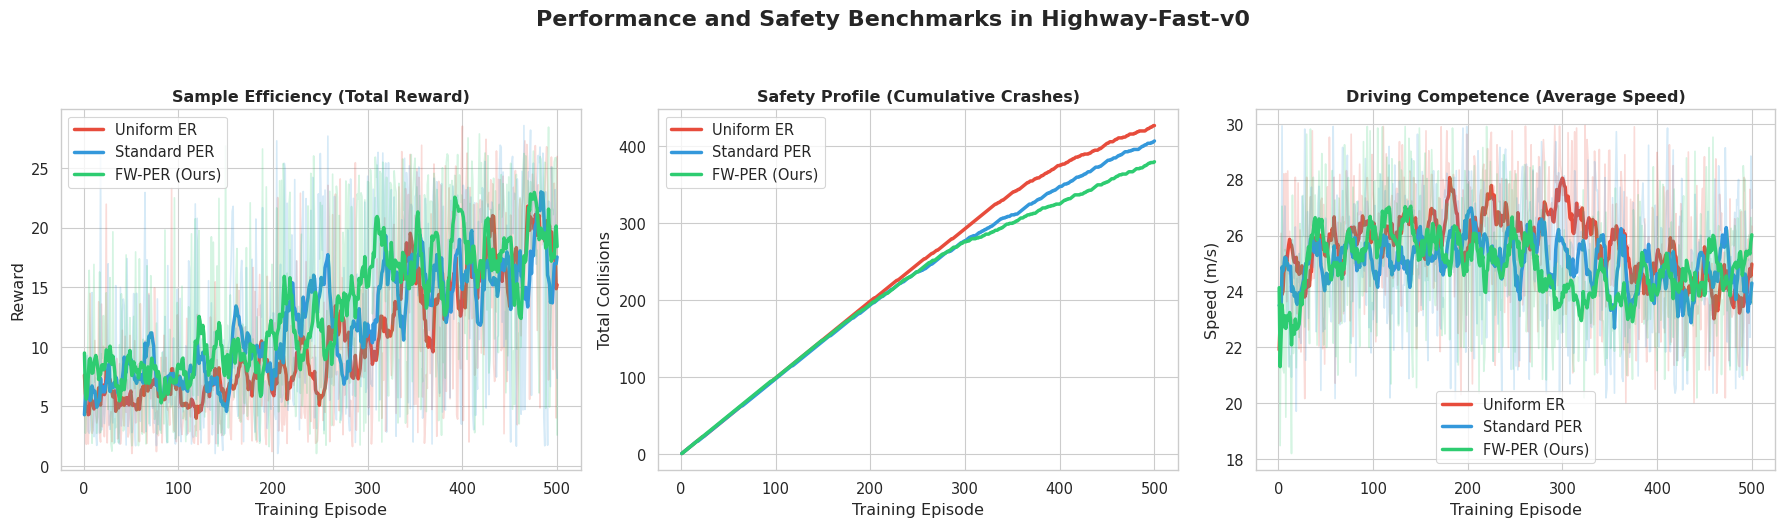

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Set professional plotting style suitable for academic journals
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

def smooth_data(data, window_size=10):
    """Applies a rolling mean to smooth out the volatile RL training data."""
    return data.rolling(window=window_size, min_periods=1).mean()

def plot_journal_results():
    # Define the files and their display labels
    experiments = {
        "Uniform ER": "q1_metrics_uniform.csv",
        "Standard PER": "q1_metrics_per.csv",
        "FW-PER (Ours)": "q1_metrics_fw_per.csv"
    }

    # Colors for the models to maintain consistency across plots
    colors = {"Uniform ER": "#e74c3c", "Standard PER": "#3498db", "FW-PER (Ours)": "#2ecc71"}

    # Initialize the figure with 3 side-by-side subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Performance and Safety Benchmarks in Highway-Fast-v0", fontsize=16, fontweight='bold', y=1.05)

    window = 10 # Smoothing window

    for label, filename in experiments.items():
        if not os.path.exists(filename):
            print(f"Warning: {filename} not found. Skipping {label}.")
            continue

        df = pd.read_csv(filename)
        episodes = df['episode']

        # --- Plot 1: Learning Curve (Sample Efficiency) ---
        raw_reward = df['reward']
        smoothed_reward = smooth_data(raw_reward, window)

        # Plot faded raw data and bold smoothed data
        axes[0].plot(episodes, raw_reward, color=colors[label], alpha=0.2)
        axes[0].plot(episodes, smoothed_reward, label=label, color=colors[label], linewidth=2.5)

        # --- Plot 2: Cumulative Collisions (Safety Metric) ---
        # Instead of just plotting 1s and 0s, a cumulative sum shows the failure rate over time.
        # A flatter line means a safer agent.
        cumulative_crashes = df['crashed'].cumsum()
        axes[1].plot(episodes, cumulative_crashes, label=label, color=colors[label], linewidth=2.5)

        # --- Plot 3: Average Speed (Driving Competence) ---
        raw_speed = df['avg_speed']
        smoothed_speed = smooth_data(raw_speed, window)

        axes[2].plot(episodes, raw_speed, color=colors[label], alpha=0.2)
        axes[2].plot(episodes, smoothed_speed, label=label, color=colors[label], linewidth=2.5)

    # --- Formatting Plot 1: Reward ---
    axes[0].set_title("Sample Efficiency (Total Reward)", fontweight='bold')
    axes[0].set_xlabel("Training Episode")
    axes[0].set_ylabel("Reward")
    axes[0].legend()

    # --- Formatting Plot 2: Safety ---
    axes[1].set_title("Safety Profile (Cumulative Crashes)", fontweight='bold')
    axes[1].set_xlabel("Training Episode")
    axes[1].set_ylabel("Total Collisions")
    axes[1].legend()

    # --- Formatting Plot 3: Speed ---
    axes[2].set_title("Driving Competence (Average Speed)", fontweight='bold')
    axes[2].set_xlabel("Training Episode")
    axes[2].set_ylabel("Speed (m/s)")
    axes[2].legend()

    plt.tight_layout()

    # Save as a high-resolution PDF (Standard requirement for Elsevier/IEEE)
    plt.savefig("FW_PER_Ablation_Results.pdf", dpi=300, bbox_inches='tight')
    plt.savefig("FW_PER_Ablation_Results.png", dpi=300, bbox_inches='tight')
    print("Plots generated successfully and saved as 'FW_PER_Ablation_Results.pdf' and '.png'")

    plt.show()

if __name__ == "__main__":
    plot_journal_results()

# FW-PER highway-env research data

In [ ]:
import gymnasium as gym
import torch
import numpy as np
import pandas as pd
import os
import traceback
from google.colab import drive

# 1. Mount Google Drive to save data permanently
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/FW_PER_Research_Data/'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Data will be saved securely to: {SAVE_DIR}")

# --- Set Global Seed for Reproducibility ---
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# --- Modified Q1 Training Loop (Accepts Seed) ---
def run_highway_experiment(experiment_mode="fw_per", max_episodes=500, seed=42):
    set_seed(seed)
    env = gym.make("highway-fast-v0")

    # Gymnasium requires seed in reset()
    raw_obs, _ = env.reset(seed=seed)
    obs_dim = raw_obs.flatten().shape[0]
    action_dim = env.action_space.n

    agent = FWPER_Agent(obs_dim=obs_dim, action_dim=action_dim, mode=experiment_mode)

    logs = {"episode": [], "reward": [], "crashed": [], "avg_speed": [], "steps_survived": []}

    epsilon, epsilon_decay, epsilon_min = 1.0, 0.995, 0.05
    total_steps = 0

    for episode in range(1, max_episodes + 1):
        obs, _ = env.reset()
        obs = obs.flatten()
        ep_reward, ep_speeds, crashed, steps_this_ep = 0, [], False, 0
        done = False

        while not done:
            total_steps += 1
            steps_this_ep += 1
            action = agent.act(obs, epsilon)
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            next_obs = next_obs.flatten()

            ep_reward += reward
            ep_speeds.append(info.get('speed', 0))
            if info.get('crashed', False): crashed = True

            with torch.no_grad():
                obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
                _, _, _, latent_z = agent.vae(obs_t)
                latent_z = latent_z.squeeze().cpu().numpy()

            agent.memory.add(obs, action, reward, next_obs, done, latent_z)

            if agent.memory.size > 200: agent.train_q_network()
            if total_steps % 250 == 0 and experiment_mode == "fw_per": agent.train_vae()
            if total_steps % 1000 == 0:
                agent.q_target.load_state_dict(agent.q_online.state_dict())
                if experiment_mode == "fw_per": agent.memory.update_semantic_rarity(agent.density_estimator)

            obs = next_obs

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        logs["episode"].append(episode)
        logs["reward"].append(ep_reward)
        logs["crashed"].append(int(crashed))
        logs["avg_speed"].append(np.mean(ep_speeds) if ep_speeds else 0)
        logs["steps_survived"].append(steps_this_ep)

        if episode % 50 == 0:
            print(f"   [Seed {seed}] Ep {episode:03d} | Reward: {ep_reward:5.1f} | Epsilon: {epsilon:.2f}")

    df = pd.DataFrame(logs)
    filename = os.path.join(SAVE_DIR, f"highway_{experiment_mode}_seed_{seed}.csv")
    df.to_csv(filename, index=False)
    print(f"-> Saved: {filename}")
    return df

# --- THE MASTER LOOP ---
if __name__ == "__main__":
    seeds = [42, 123, 456, 789, 999]
    modes = ["uniform", "per", "fw_per"]
    max_episodes = 500

    print("\n" + "="*50)
    print("STARTING Q1 EXPERIMENT BATCH (15 Total Runs)")
    print("="*50)

    for mode in modes:
        for seed in seeds:
            print(f"\n--- Running Mode: {mode.upper()} | Seed: {seed} ---")
            try:
                run_highway_experiment(experiment_mode=mode, max_episodes=max_episodes, seed=seed)
            except Exception as e:
                print(f"!!! ERROR ON {mode} SEED {seed} !!!")
                print(traceback.format_exc())
                print("Continuing to next run...")

    print("\n" + "="*50)
    print("ALL EXPERIMENTS COMPLETED. DATA SAVED TO GOOGLE DRIVE.")
    print("="*50)

Mounted at /content/drive
Data will be saved securely to: /content/drive/MyDrive/FW_PER_Research_Data/

STARTING Q1 EXPERIMENT BATCH (15 Total Runs)

--- Running Mode: UNIFORM | Seed: 42 ---
   [Seed 42] Ep 050 | Reward:   4.5 | Epsilon: 0.78
   [Seed 42] Ep 100 | Reward:   6.7 | Epsilon: 0.61
   [Seed 42] Ep 150 | Reward:   7.4 | Epsilon: 0.47
   [Seed 42] Ep 200 | Reward:  22.3 | Epsilon: 0.37
   [Seed 42] Ep 250 | Reward:   6.5 | Epsilon: 0.29
   [Seed 42] Ep 300 | Reward:   5.9 | Epsilon: 0.22
   [Seed 42] Ep 350 | Reward:  10.8 | Epsilon: 0.17
   [Seed 42] Ep 400 | Reward:  23.9 | Epsilon: 0.13
   [Seed 42] Ep 450 | Reward:  18.9 | Epsilon: 0.10
   [Seed 42] Ep 500 | Reward:   8.6 | Epsilon: 0.08
-> Saved: /content/drive/MyDrive/FW_PER_Research_Data/highway_uniform_seed_42.csv

--- Running Mode: UNIFORM | Seed: 123 ---
   [Seed 123] Ep 050 | Reward:   2.6 | Epsilon: 0.78
   [Seed 123] Ep 100 | Reward:   8.0 | Epsilon: 0.61
   [Seed 123] Ep 150 | Reward:   2.0 | Epsilon: 0.47
   [S

Aggregating 15 CSV files...
Generating statistical graphs with Standard Deviation shading...
Graph saved successfully to: /content/drive/MyDrive/FW_PER_Research_Data/Highway_MultiSeed_Results.png


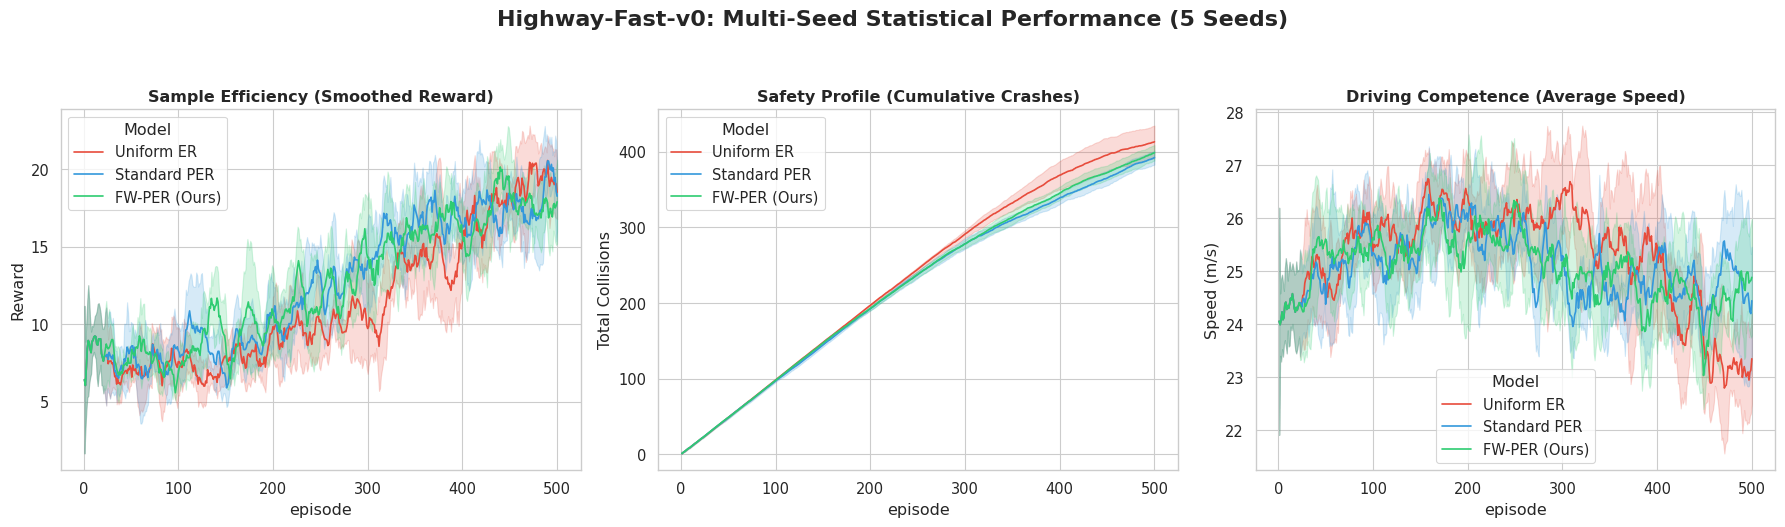

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

SAVE_DIR = '/content/drive/MyDrive/FW_PER_Research_Data/'
modes = {"uniform": "Uniform ER", "per": "Standard PER", "fw_per": "FW-PER (Ours)"}
seeds = [42, 123, 456, 789, 999]
colors = {"Uniform ER": "#e74c3c", "Standard PER": "#3498db", "FW-PER (Ours)": "#2ecc71"}

print("Aggregating 15 CSV files...")
all_data = []

# Load and aggregate all 15 runs
for mode_key, mode_name in modes.items():
    for seed in seeds:
        filename = os.path.join(SAVE_DIR, f"highway_{mode_key}_seed_{seed}.csv")
        if os.path.exists(filename):
            df = pd.read_csv(filename)
            df['seed'] = seed
            df['Model'] = mode_name
            # Calculate cumulative crashes for this specific seed before aggregating
            df['cumulative_crashes'] = df['crashed'].cumsum()

            # Apply a small rolling window to smooth the incredibly noisy raw RL rewards
            df['smoothed_reward'] = df['reward'].rolling(window=10, min_periods=1).mean()
            df['smoothed_speed'] = df['avg_speed'].rolling(window=10, min_periods=1).mean()

            all_data.append(df)
        else:
            print(f"Warning: {filename} not found.")

final_df = pd.concat(all_data, ignore_index=True)

# --- Plotting the Statistical Q1 Graphs ---
print("Generating statistical graphs with Standard Deviation shading...")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Highway-Fast-v0: Multi-Seed Statistical Performance (5 Seeds)", fontsize=16, fontweight='bold', y=1.05)

# 1. Reward (Sample Efficiency)
# errorbar='sd' tells seaborn to automatically shade the Standard Deviation
sns.lineplot(data=final_df, x='episode', y='smoothed_reward', hue='Model', palette=colors, ax=axes[0], errorbar='sd')
axes[0].set_title("Sample Efficiency (Smoothed Reward)", fontweight='bold')
axes[0].set_ylabel("Reward")

# 2. Cumulative Crashes (Safety Profile)
sns.lineplot(data=final_df, x='episode', y='cumulative_crashes', hue='Model', palette=colors, ax=axes[1], errorbar='sd')
axes[1].set_title("Safety Profile (Cumulative Crashes)", fontweight='bold')
axes[1].set_ylabel("Total Collisions")

# 3. Driving Competence (Speed)
sns.lineplot(data=final_df, x='episode', y='smoothed_speed', hue='Model', palette=colors, ax=axes[2], errorbar='sd')
axes[2].set_title("Driving Competence (Average Speed)", fontweight='bold')
axes[2].set_ylabel("Speed (m/s)")

plt.tight_layout()
save_path = os.path.join(SAVE_DIR, "Highway_MultiSeed_Results.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Graph saved successfully to: {save_path}")
plt.show()

# FW-PER mountain-env

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import os
import traceback
from google.colab import drive

# ==========================================
# 1. SETUP & GOOGLE DRIVE
# ==========================================
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/FW_PER_Research_Data_MC/'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Data will be saved securely to: {SAVE_DIR}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# ==========================================
# 2. NEURAL NETWORKS
# ==========================================
class QNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(obs_dim, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

class StateVAE(nn.Module):
    # Latent dimension set to 2 for the 2D MountainCar observation space
    def __init__(self, input_dim, latent_dim=2):
        super(StateVAE, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)
        self.fc3 = nn.Linear(latent_dim, 64)
        self.fc4 = nn.Linear(64, input_dim)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar, z

class LatentDensityEstimator:
    def __init__(self, k=10, eta=1e-5):
        self.k = k
        self.eta = eta

    def compute_phi(self, z_batch, z_buffer=None):
        if z_buffer is None: z_buffer = z_batch
        distances = torch.cdist(z_batch, z_buffer, p=2.0)
        topk_dist, _ = torch.topk(distances, self.k + 1, largest=False, dim=1)
        knn_dist = topk_dist[:, 1:]
        rho = 1.0 / (knn_dist.mean(dim=1) + self.eta)
        phi = torch.log(1.0 + (1.0 / (rho + self.eta)))
        return phi

# ==========================================
# 3. FIXED FW-PER BUFFER (WITH NORMALIZATION)
# ==========================================
class FeatureWeightedReplayBuffer:
    def __init__(self, capacity, obs_dim, latent_dim, alpha=0.6, epsilon=1e-3):
        self.capacity = capacity
        self.alpha = alpha
        self.epsilon = epsilon
        self.ptr = 0
        self.size = 0

        self.states = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, 1), dtype=np.int64)
        self.rewards = np.zeros((capacity, 1), dtype=np.float32)
        self.next_states = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.dones = np.zeros((capacity, 1), dtype=np.float32)

        self.latents = np.zeros((capacity, latent_dim), dtype=np.float32)
        self.td_errors = np.zeros(capacity, dtype=np.float32)
        self.phi_scores = np.ones(capacity, dtype=np.float32)
        self.priorities = np.zeros(capacity, dtype=np.float32)

    def _recalculate_priorities(self):
        if self.size == 0: return
        current_tds = self.td_errors[:self.size]
        td_min, td_max = current_tds.min(), current_tds.max()

        if td_max > td_min:
            norm_tds = (current_tds - td_min) / (td_max - td_min + 1e-8)
        else:
            norm_tds = np.zeros(self.size)

        self.priorities[:self.size] = (norm_tds + self.epsilon) * self.phi_scores[:self.size]

    def add(self, state, action, reward, next_state, done, latent_z):
        max_prio = self.priorities.max() if self.size > 0 else 1.0
        self.states[self.ptr] = state
        self.actions[self.ptr] = action
        self.rewards[self.ptr] = reward
        self.next_states[self.ptr] = next_state
        self.dones[self.ptr] = done
        self.latents[self.ptr] = latent_z
        self.priorities[self.ptr] = max_prio

        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def update_priorities(self, batch_indices, batch_td_errors):
        for i, idx in enumerate(batch_indices):
            self.td_errors[idx] = abs(batch_td_errors[i])
        self._recalculate_priorities()

    def update_semantic_rarity(self, density_estimator):
        if self.size < 100: return
        z_buffer = torch.FloatTensor(self.latents[:self.size]).to(device)
        with torch.no_grad():
            new_phis = density_estimator.compute_phi(z_buffer, z_buffer).cpu().numpy()
        self.phi_scores[:self.size] = new_phis
        self._recalculate_priorities()

    def sample(self, batch_size, beta=0.4):
        if self.size == 0: return None
        prios = self.priorities[:self.size]
        probs = prios ** self.alpha
        if probs.sum() == 0: return None
        probs /= probs.sum()

        indices = np.random.choice(self.size, batch_size, p=probs)
        total = self.size
        weights = (total * probs[indices]) ** (-beta)
        weights /= weights.max()

        batch = (
            torch.FloatTensor(self.states[indices]).to(device),
            torch.LongTensor(self.actions[indices]).to(device),
            torch.FloatTensor(self.rewards[indices]).to(device),
            torch.FloatTensor(self.next_states[indices]).to(device),
            torch.FloatTensor(self.dones[indices]).to(device),
            torch.FloatTensor(weights).to(device),
            indices
        )
        return batch

# ==========================================
# 4. FW-PER AGENT
# ==========================================
class FWPER_Agent:
    def __init__(self, obs_dim, action_dim, mode="fw_per"):
        self.action_dim = action_dim
        self.obs_dim = obs_dim
        self.mode = mode

        self.q_online = QNetwork(obs_dim, action_dim).to(device)
        self.q_target = QNetwork(obs_dim, action_dim).to(device)
        self.q_target.load_state_dict(self.q_online.state_dict())
        self.q_optimizer = torch.optim.Adam(self.q_online.parameters(), lr=5e-4)

        self.memory = FeatureWeightedReplayBuffer(capacity=15000, obs_dim=obs_dim, latent_dim=2)
        if self.mode == "uniform":
            self.memory.alpha = 0.0
        else:
            self.memory.alpha = 0.6

        self.vae = StateVAE(input_dim=obs_dim, latent_dim=2).to(device)
        self.vae_optimizer = torch.optim.Adam(self.vae.parameters(), lr=1e-3)
        self.density_estimator = LatentDensityEstimator(k=10)

    def act(self, state, epsilon=0.1):
        if np.random.rand() < epsilon: return np.random.randint(self.action_dim)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            return self.q_online(state_t).argmax().item()

    def train_q_network(self, batch_size=64, gamma=0.99):
        batch = self.memory.sample(batch_size)
        if batch is None: return
        states, actions, rewards, next_states, dones, weights, indices = batch
        with torch.no_grad():
            next_actions = self.q_online(next_states).argmax(1, keepdim=True)
            next_q = self.q_target(next_states).gather(1, next_actions)
            target_q = rewards + gamma * next_q * (1 - dones)
        current_q = self.q_online(states).gather(1, actions)
        td_errors = (target_q - current_q).squeeze().detach().cpu().numpy()
        self.memory.update_priorities(indices, td_errors)
        loss = (weights * F.mse_loss(current_q, target_q, reduction='none')).mean()
        self.q_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_online.parameters(), 1.0)
        self.q_optimizer.step()

    def train_vae(self, batch_size=128, beta=1.0):
        if self.memory.size < batch_size: return
        indices = np.random.choice(self.memory.size, batch_size)
        states = torch.FloatTensor(self.memory.states[indices]).to(device)
        self.vae_optimizer.zero_grad()
        recon, mu, logvar, _ = self.vae(states)
        recon_loss = F.mse_loss(recon, states, reduction='mean')
        kld_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + beta * kld_loss
        loss.backward()
        self.vae_optimizer.step()

# ==========================================
# 5. EXPERIMENT RUNNER
# ==========================================
def run_experiment(env_name="MountainCar-v0", experiment_mode="fw_per", max_episodes=500, seed=42):
    set_seed(seed)

    env = gym.make(env_name)
    raw_obs, _ = env.reset(seed=seed)
    obs_dim = raw_obs.flatten().shape[0]
    action_dim = env.action_space.n

    agent = FWPER_Agent(obs_dim=obs_dim, action_dim=action_dim, mode=experiment_mode)

    logs = {"episode": [], "reward": [], "solved": []}

    # MountainCar requires a slightly slower decay to ensure it explores enough to find the flag initially
    epsilon, epsilon_decay, epsilon_min = 1.0, 0.995, 0.05
    total_steps = 0

    for episode in range(1, max_episodes + 1):
        obs, _ = env.reset()
        obs = obs.flatten()
        ep_reward = 0
        done = False

        while not done:
            total_steps += 1
            action = agent.act(obs, epsilon)
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            next_obs = next_obs.flatten()

            ep_reward += reward

            with torch.no_grad():
                obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
                _, _, _, latent_z = agent.vae(obs_t)
                latent_z = latent_z.squeeze().cpu().numpy()

            agent.memory.add(obs, action, reward, next_obs, done, latent_z)

            if agent.memory.size > 200: agent.train_q_network()
            if total_steps % 250 == 0 and experiment_mode == "fw_per": agent.train_vae()
            if total_steps % 1000 == 0:
                agent.q_target.load_state_dict(agent.q_online.state_dict())
                if experiment_mode == "fw_per": agent.memory.update_semantic_rarity(agent.density_estimator)

            obs = next_obs

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        # MountainCar is solved if it takes less than 200 steps (meaning reward > -200)
        solved = 1 if ep_reward > -200 else 0

        logs["episode"].append(episode)
        logs["reward"].append(ep_reward)
        logs["solved"].append(solved)

        if episode % 50 == 0:
            status = "SOLVED" if solved else "Failed"
            print(f"   [Seed {seed}] Ep {episode:03d} | Reward: {ep_reward:6.1f} | Epsilon: {epsilon:.2f} | {status}")

    df = pd.DataFrame(logs)
    filename = os.path.join(SAVE_DIR, f"mountaincar_{experiment_mode}_seed_{seed}.csv")
    df.to_csv(filename, index=False)
    print(f"-> Saved: {filename}")
    return df

# ==========================================
# 6. MASTER EXECUTION LOOP
# ==========================================
if __name__ == "__main__":
    seeds = [42, 123, 456, 789, 999]
    modes = ["uniform", "per", "fw_per"]
    max_episodes = 500
    env_target = "MountainCar-v0"

    print("\n" + "="*50)
    print(f"STARTING EXPERIMENT: {env_target.upper()} (15 Total Runs)")
    print("="*50)

    for mode in modes:
        for seed in seeds:
            print(f"\n--- Running Mode: {mode.upper()} | Seed: {seed} ---")
            try:
                run_experiment(env_name=env_target, experiment_mode=mode, max_episodes=max_episodes, seed=seed)
            except Exception as e:
                print(f"!!! ERROR ON {mode} SEED {seed} !!!")
                print(traceback.format_exc())
                print("Continuing to next run...")

    print("\n" + "="*50)
    print("ALL RUNS COMPLETED. DATA SAVED TO GOOGLE DRIVE.")
    print("="*50)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data will be saved securely to: /content/drive/MyDrive/FW_PER_Research_Data_MC/

STARTING EXPERIMENT: MOUNTAINCAR-V0 (15 Total Runs)

--- Running Mode: UNIFORM | Seed: 42 ---
   [Seed 42] Ep 050 | Reward: -200.0 | Epsilon: 0.78 | Failed
   [Seed 42] Ep 100 | Reward: -200.0 | Epsilon: 0.61 | Failed
   [Seed 42] Ep 150 | Reward: -200.0 | Epsilon: 0.47 | Failed
   [Seed 42] Ep 200 | Reward: -200.0 | Epsilon: 0.37 | Failed
   [Seed 42] Ep 250 | Reward: -200.0 | Epsilon: 0.29 | Failed
   [Seed 42] Ep 300 | Reward: -200.0 | Epsilon: 0.22 | Failed
   [Seed 42] Ep 350 | Reward: -200.0 | Epsilon: 0.17 | Failed
   [Seed 42] Ep 400 | Reward: -200.0 | Epsilon: 0.13 | Failed
   [Seed 42] Ep 450 | Reward: -200.0 | Epsilon: 0.10 | Failed
   [Seed 42] Ep 500 | Reward: -200.0 | Epsilon: 0.08 | Failed
-> Saved: /content/drive/MyDrive/FW_PER_Research_Data_MC/mountaincar_uniform

Aggregating 15 MountainCar CSV files...
Generating corrected Q2-Standard graphs...
Graph saved successfully to: /content/drive/MyDrive/FW_PER_Research_Data_MC/MountainCar_MultiSeed_Results.pdf


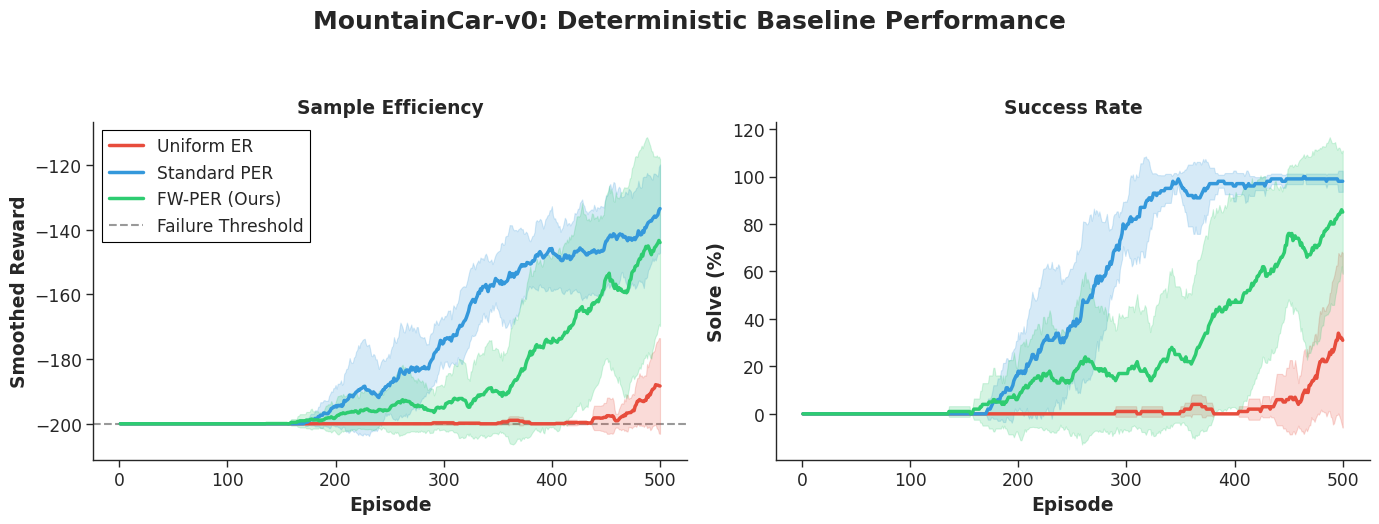

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

SAVE_DIR = '/content/drive/MyDrive/FW_PER_Research_Data_MC/'
modes = {"uniform": "Uniform ER", "per": "Standard PER", "fw_per": "FW-PER (Ours)"}
seeds = [42, 123, 456, 789, 999]
colors = {"Uniform ER": "#e74c3c", "Standard PER": "#3498db", "FW-PER (Ours)": "#2ecc71"}

plt.rcParams.update({
    "font.family": "serif",
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5
})

print("Aggregating 15 MountainCar CSV files...")
all_data = []

for mode_key, mode_name in modes.items():
    for seed in seeds:
        filename = os.path.join(SAVE_DIR, f"mountaincar_{mode_key}_seed_{seed}.csv")
        if os.path.exists(filename):
            df = pd.read_csv(filename)
            df['seed'] = seed
            df['Model'] = mode_name
            df['smoothed_reward'] = df['reward'].rolling(window=20, min_periods=1).mean()
            df['success_rate'] = df['solved'].rolling(window=20, min_periods=1).mean() * 100
            all_data.append(df)

final_df = pd.concat(all_data, ignore_index=True)

print("Generating corrected Q2-Standard graphs...")
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.4)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MountainCar-v0: Deterministic Baseline Performance", fontsize=18, fontweight='bold', y=1.05)

# Plot 1: Reward
sns.lineplot(data=final_df, x='episode', y='smoothed_reward', hue='Model', palette=colors, ax=axes[0], errorbar='sd', linewidth=2.5)
# Ensure the threshold line stays behind the data (zorder=0)
axes[0].axhline(-200, color='gray', linestyle='--', alpha=0.8, linewidth=1.5, label='Failure Threshold', zorder=0)
axes[0].set_title("Sample Efficiency", fontweight='bold')
axes[0].set_ylabel("Smoothed Reward", fontweight='bold')
axes[0].set_xlabel("Episode", fontweight='bold')

# FIX: Move legend to the empty TOP LEFT and give it a solid white background with a sharp border
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles, labels=labels, title="", loc="upper left", frameon=True, edgecolor='black', framealpha=1.0, fancybox=False)

# Plot 2: Success Rate
sns.lineplot(data=final_df, x='episode', y='success_rate', hue='Model', palette=colors, ax=axes[1], errorbar='sd', linewidth=2.5)
axes[1].set_title("Success Rate", fontweight='bold')
axes[1].set_ylabel("Solve (%)", fontweight='bold')
axes[1].set_xlabel("Episode", fontweight='bold')
axes[1].get_legend().remove()

sns.despine()
plt.tight_layout()

save_path = os.path.join(SAVE_DIR, "MountainCar_MultiSeed_Results.pdf")
plt.savefig(save_path, format='pdf', dpi=300, bbox_inches='tight')
print(f"Graph saved successfully to: {save_path}")
plt.show()

# FW-PER noisy-tv

In [ ]:
import gymnasium as gym
from gymnasium.wrappers import NormalizeObservation
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import os
import traceback
from google.colab import drive

# ==========================================
# 1. SETUP & GOOGLE DRIVE
# ==========================================
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/FW_PER_Research_Data_PURE/'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Data will be saved securely to: {SAVE_DIR}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# ==========================================
# 2. NORMALIZED NOISY TV WRAPPER
# ==========================================
class NoisyTVWrapper(gym.ObservationWrapper):
    def __init__(self, env, noise_dim=10, noise_scale=5.0):
        super().__init__(env)
        self.noise_dim = noise_dim
        self.noise_scale = noise_scale
        old_space = env.observation_space
        new_low = np.append(old_space.low, np.full(noise_dim, -np.inf, dtype=np.float32))
        new_high = np.append(old_space.high, np.full(noise_dim, np.inf, dtype=np.float32))
        self.observation_space = gym.spaces.Box(low=new_low, high=new_high, dtype=np.float32)

    def observation(self, obs):
        noise = (np.random.randn(self.noise_dim) * self.noise_scale).astype(np.float32)
        return np.concatenate([obs, noise])

def make_noisy_lander():
    # Using v3 as you correctly identified earlier
    base_env = gym.make("LunarLander-v3")
    noisy_env = NoisyTVWrapper(base_env, noise_dim=10)
    return NormalizeObservation(noisy_env)

# ==========================================
# 3. INVERSE DYNAMICS NETWORKS
# ==========================================
class QNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super().__init__()
        self.fc1 = nn.Linear(obs_dim, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

class StateEncoder(nn.Module):
    def __init__(self, input_dim, latent_dim=4):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, latent_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x)

class InverseModel(nn.Module):
    def __init__(self, latent_dim, action_dim):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim * 2, 64)
        self.fc2 = nn.Linear(64, action_dim)

    def forward(self, z_t, z_next):
        x = torch.cat([z_t, z_next], dim=1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

class LatentDensityEstimator:
    def __init__(self, k=10, eta=1e-5):
        self.k = k
        self.eta = eta

    def compute_phi(self, z_batch, z_bank):
        distances = torch.cdist(z_batch, z_bank, p=2.0)
        topk_dist, _ = torch.topk(distances, self.k, largest=False, dim=1)
        rho = 1.0 / (topk_dist.mean(dim=1) + self.eta)
        phi = torch.log(1.0 + (1.0 / (rho + self.eta)))
        return phi

# ==========================================
# 4. RAW-STORAGE REPLAY BUFFER
# ==========================================
class FeatureWeightedReplayBuffer:
    def __init__(self, capacity, obs_dim, alpha=0.6, epsilon=1e-3):
        self.capacity = capacity
        self.alpha = alpha
        self.epsilon = epsilon
        self.ptr = 0
        self.size = 0

        self.states = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, 1), dtype=np.int64)
        self.rewards = np.zeros((capacity, 1), dtype=np.float32)
        self.next_states = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.dones = np.zeros((capacity, 1), dtype=np.float32)
        self.priorities = np.zeros(capacity, dtype=np.float32)

    def add(self, state, action, reward, next_state, done):
        max_prio = self.priorities.max() if self.size > 0 else 1.0
        self.states[self.ptr] = state
        self.actions[self.ptr] = action
        self.rewards[self.ptr] = reward
        self.next_states[self.ptr] = next_state
        self.dones[self.ptr] = done
        self.priorities[self.ptr] = max_prio

        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def update_priorities(self, batch_indices, new_priorities):
        for i, idx in enumerate(batch_indices):
            self.priorities[idx] = new_priorities[i]

    def sample(self, batch_size, beta=0.4):
        if self.size == 0: return None
        prios = self.priorities[:self.size]
        probs = prios ** self.alpha
        if probs.sum() == 0: return None
        probs /= probs.sum()
        indices = np.random.choice(self.size, batch_size, p=probs)
        weights = (self.size * probs[indices]) ** (-beta)
        weights /= weights.max()

        batch = (
            torch.FloatTensor(self.states[indices]).to(device),
            torch.LongTensor(self.actions[indices]).to(device),
            torch.FloatTensor(self.rewards[indices]).to(device),
            torch.FloatTensor(self.next_states[indices]).to(device),
            torch.FloatTensor(self.dones[indices]).to(device),
            torch.FloatTensor(weights).to(device),
            indices
        )
        return batch

    def sample_raw_states(self, batch_size):
        indices = np.random.choice(self.size, min(batch_size, self.size), replace=False)
        return torch.FloatTensor(self.states[indices]).to(device)

# ==========================================
# 5. THE PURE SEMANTIC AGENT
# ==========================================
class FWPER_Agent:
    def __init__(self, obs_dim, action_dim, mode="fw_per"):
        self.action_dim = action_dim
        self.obs_dim = obs_dim
        self.mode = mode

        self.q_online = QNetwork(obs_dim, action_dim).to(device)
        self.q_target = QNetwork(obs_dim, action_dim).to(device)
        self.q_target.load_state_dict(self.q_online.state_dict())
        self.q_optimizer = torch.optim.Adam(self.q_online.parameters(), lr=5e-4)

        self.memory = FeatureWeightedReplayBuffer(capacity=15000, obs_dim=obs_dim)
        self.memory.alpha = 0.0 if self.mode == "uniform" else 0.6

        self.encoder = StateEncoder(input_dim=obs_dim, latent_dim=4).to(device)
        self.inverse_model = InverseModel(latent_dim=4, action_dim=action_dim).to(device)
        self.encoder_optimizer = torch.optim.Adam(
            list(self.encoder.parameters()) + list(self.inverse_model.parameters()), lr=1e-3
        )

        self.density_estimator = LatentDensityEstimator(k=10)
        self.global_z_bank = None

    def act(self, state, epsilon=0.1):
        if np.random.rand() < epsilon: return np.random.randint(self.action_dim)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            return self.q_online(state_t).argmax().item()

    def update_global_bank(self, sample_size=2000):
        if self.mode != "fw_per" or self.memory.size < 500: return
        raw_states = self.memory.sample_raw_states(sample_size)
        with torch.no_grad():
            self.global_z_bank = self.encoder(raw_states)

    def train_step(self, batch_size=128, gamma=0.99):
        if self.memory.size < batch_size: return
        batch = self.memory.sample(batch_size)
        if batch is None: return
        states, actions, rewards, next_states, dones, weights, indices = batch

        phi_scores = np.ones(batch_size)

        # --- INVERSE DYNAMICS ---
        if self.mode == "fw_per":
            z_t = self.encoder(states)
            z_next = self.encoder(next_states)
            action_preds = self.inverse_model(z_t, z_next)
            inv_loss = F.cross_entropy(action_preds, actions.squeeze(-1))

            self.encoder_optimizer.zero_grad()
            inv_loss.backward()
            self.encoder_optimizer.step()

            if self.global_z_bank is not None:
                with torch.no_grad():
                    fresh_z = self.encoder(states)
                    phi_scores = self.density_estimator.compute_phi(fresh_z, self.global_z_bank).cpu().numpy()

        # --- Q-NETWORK LEARNING ---
        with torch.no_grad():
            next_actions = self.q_online(next_states).argmax(1, keepdim=True)
            next_q = self.q_target(next_states).gather(1, next_actions)
            target_q = rewards + gamma * next_q * (1 - dones)

        current_q = self.q_online(states).gather(1, actions)
        td_errors = (target_q - current_q).squeeze().detach().cpu().numpy()

        # ==========================================
        # THE AMPUTATION: THE CRITICAL PRIORITY MATH
        # ==========================================
        if self.mode == "fw_per":
            # PURE SEMANTIC: TD-Error is completely deleted. Priority is ONLY Phi.
            new_priorities = phi_scores + self.memory.epsilon
        elif self.mode == "per":
            # PURE TD-ERROR: The standard baseline.
            new_priorities = np.abs(td_errors) + self.memory.epsilon
        else:
            # UNIFORM
            new_priorities = np.ones(batch_size)

        # Normalize priorities to keep the buffer stable
        p_min, p_max = new_priorities.min(), new_priorities.max()
        if p_max > p_min:
            new_priorities = (new_priorities - p_min) / (p_max - p_min + 1e-8) + self.memory.epsilon

        self.memory.update_priorities(indices, new_priorities)

        q_loss = (weights * F.mse_loss(current_q, target_q, reduction='none')).mean()
        self.q_optimizer.zero_grad()
        q_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_online.parameters(), 1.0)
        self.q_optimizer.step()

# ==========================================
# 6. EXPERIMENT RUNNER & MASTER LOOP
# ==========================================
def run_experiment(env_name="noisy_lander", experiment_mode="fw_per", max_episodes=500, seed=42):
    set_seed(seed)
    env = make_noisy_lander() if env_name == "noisy_lander" else NormalizeObservation(gym.make("LunarLander-v3"))
    raw_obs, _ = env.reset(seed=seed)
    obs_dim = raw_obs.flatten().shape[0]
    action_dim = env.action_space.n

    agent = FWPER_Agent(obs_dim=obs_dim, action_dim=action_dim, mode=experiment_mode)
    logs = {"episode": [], "reward": [], "steps_survived": [], "solved": []}

    epsilon, epsilon_decay, epsilon_min = 1.0, 0.995, 0.05
    total_steps = 0
    agent.update_global_bank()

    for episode in range(1, max_episodes + 1):
        obs, _ = env.reset()
        obs = obs.flatten()
        ep_reward, steps_this_ep = 0, 0
        done = False

        while not done:
            total_steps += 1
            steps_this_ep += 1
            action = agent.act(obs, epsilon)
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            next_obs = next_obs.flatten()

            ep_reward += reward
            agent.memory.add(obs, action, reward, next_obs, done)

            if agent.memory.size > 200:
                agent.train_step()

            if total_steps % 1000 == 0:
                agent.q_target.load_state_dict(agent.q_online.state_dict())
                agent.update_global_bank()

            obs = next_obs

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        solved = 1 if ep_reward >= 200 else 0

        logs["episode"].append(episode)
        logs["reward"].append(ep_reward)
        logs["steps_survived"].append(steps_this_ep)
        logs["solved"].append(solved)

        if episode % 50 == 0:
            print(f"   [Seed {seed}] Ep {episode:03d} | Reward: {ep_reward:7.1f} | Epsilon: {epsilon:.2f}")

    df = pd.DataFrame(logs)
    filename = os.path.join(SAVE_DIR, f"{env_name}_{experiment_mode}_seed_{seed}.csv")
    df.to_csv(filename, index=False)
    print(f"-> Saved: {filename}")
    return df

if __name__ == "__main__":
    seeds = [42, 123, 456, 789, 999]
    modes = ["uniform", "per", "fw_per"]
    max_episodes = 500
    env_target = "noisy_lander"

    print("\n" + "="*50)
    print(f"STARTING 'PURE SEMANTIC' PROTOCOL: {env_target.upper()} (15 Runs)")
    print("="*50)

    for mode in modes:
        for seed in seeds:
            print(f"\n--- Running Mode: {mode.upper()} | Seed: {seed} ---")
            try:
                run_experiment(env_name=env_target, experiment_mode=mode, max_episodes=max_episodes, seed=seed)
            except Exception as e:
                print(f"!!! ERROR ON {mode} SEED {seed} !!!")
                print(traceback.format_exc())
                print("Continuing to next run...")

    print("\n" + "="*50)
    print("ALL RUNS COMPLETED.")
    print("="*50)

Mounted at /content/drive
Data will be saved securely to: /content/drive/MyDrive/FW_PER_Research_Data_PURE/

STARTING 'PURE SEMANTIC' PROTOCOL: NOISY_LANDER (15 Runs)

--- Running Mode: UNIFORM | Seed: 42 ---
   [Seed 42] Ep 050 | Reward:  -133.9 | Epsilon: 0.78
   [Seed 42] Ep 100 | Reward:   -89.3 | Epsilon: 0.61
   [Seed 42] Ep 150 | Reward:   -65.2 | Epsilon: 0.47
   [Seed 42] Ep 200 | Reward:   -38.7 | Epsilon: 0.37
   [Seed 42] Ep 250 | Reward:   -35.1 | Epsilon: 0.29
   [Seed 42] Ep 300 | Reward:   -28.5 | Epsilon: 0.22
   [Seed 42] Ep 350 | Reward:    42.7 | Epsilon: 0.17
   [Seed 42] Ep 400 | Reward:   -59.7 | Epsilon: 0.13
   [Seed 42] Ep 450 | Reward:    26.8 | Epsilon: 0.10
   [Seed 42] Ep 500 | Reward:   -87.2 | Epsilon: 0.08
-> Saved: /content/drive/MyDrive/FW_PER_Research_Data_PURE/noisy_lander_uniform_seed_42.csv

--- Running Mode: UNIFORM | Seed: 123 ---
   [Seed 123] Ep 050 | Reward:  -109.5 | Epsilon: 0.78
   [Seed 123] Ep 100 | Reward:   -80.7 | Epsilon: 0.61
   [Se

Aggregating 15 Noisy TV CSV files...
Generating Q2-Standard graphs with large text...
Graph saved successfully to: /content/drive/MyDrive/FW_PER_Research_Data_PURE/Noisy_TV_MultiSeed_Results_2.pdf


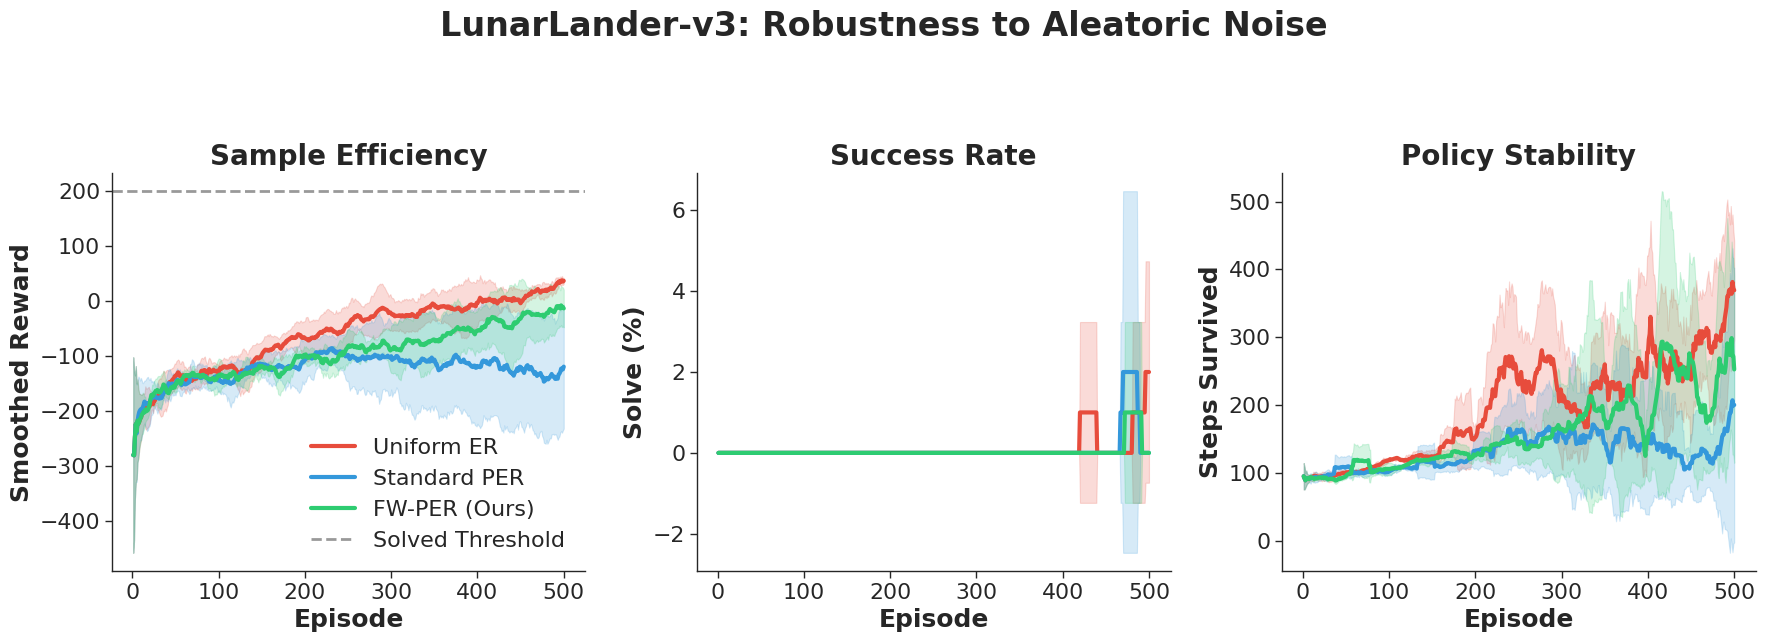

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

SAVE_DIR = '/content/drive/MyDrive/FW_PER_Research_Data_PURE/'
modes = {"uniform": "Uniform ER", "per": "Standard PER", "fw_per": "FW-PER (Ours)"}
seeds = [42, 123, 456, 789, 999]
colors = {"Uniform ER": "#e74c3c", "Standard PER": "#3498db", "FW-PER (Ours)": "#2ecc71"}

# GLOBALLY BOOSTED JOURNAL FORMATTING
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 16,
    "axes.titlesize": 20,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 2.0,
    "xtick.major.width": 2.0,
    "ytick.major.width": 2.0,
    "legend.frameon": False
})

print("Aggregating 15 Noisy TV CSV files...")
all_data = []

for mode_key, mode_name in modes.items():
    for seed in seeds:
        filename = os.path.join(SAVE_DIR, f"noisy_lander_{mode_key}_seed_{seed}.csv")
        if os.path.exists(filename):
            df = pd.read_csv(filename)
            df['seed'] = seed
            df['Model'] = mode_name
            df['smoothed_reward'] = df['reward'].rolling(window=20, min_periods=1).mean()
            df['success_rate'] = df['solved'].rolling(window=20, min_periods=1).mean() * 100
            df['smoothed_steps'] = df['steps_survived'].rolling(window=20, min_periods=1).mean()
            all_data.append(df)

final_df = pd.concat(all_data, ignore_index=True)

print("Generating Q2-Standard graphs with large text...")
sns.set_style("ticks")
# Boosted the base Seaborn scale
sns.set_context("paper", font_scale=1.8)

fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Slightly taller
fig.suptitle("LunarLander-v3: Robustness to Aleatoric Noise", fontsize=24, fontweight='bold', y=1.08)

# Plot 1: Reward
sns.lineplot(data=final_df, x='episode', y='smoothed_reward', hue='Model', palette=colors, ax=axes[0], errorbar='sd', linewidth=3.0)
axes[0].axhline(200, color='gray', linestyle='--', alpha=0.8, linewidth=2.0, label='Solved Threshold')
axes[0].set_title("Sample Efficiency", fontweight='bold', fontsize=20)
axes[0].set_ylabel("Smoothed Reward", fontweight='bold', fontsize=18)
axes[0].set_xlabel("Episode", fontweight='bold', fontsize=18)
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles, labels=labels, title="", loc="lower right", fontsize=16)

# Plot 2: Success Rate
sns.lineplot(data=final_df, x='episode', y='success_rate', hue='Model', palette=colors, ax=axes[1], errorbar='sd', linewidth=3.0)
axes[1].set_title("Success Rate", fontweight='bold', fontsize=20)
axes[1].set_ylabel("Solve (%)", fontweight='bold', fontsize=18)
axes[1].set_xlabel("Episode", fontweight='bold', fontsize=18)
axes[1].get_legend().remove()

# Plot 3: Steps Survived
sns.lineplot(data=final_df, x='episode', y='smoothed_steps', hue='Model', palette=colors, ax=axes[2], errorbar='sd', linewidth=3.0)
axes[2].set_title("Policy Stability", fontweight='bold', fontsize=20)
axes[2].set_ylabel("Steps Survived", fontweight='bold', fontsize=18)
axes[2].set_xlabel("Episode", fontweight='bold', fontsize=18)
axes[2].get_legend().remove()

sns.despine()
plt.tight_layout()

save_path = os.path.join(SAVE_DIR, "Noisy_TV_MultiSeed_Results_2.pdf")
plt.savefig(save_path, format='pdf', dpi=300, bbox_inches='tight')
print(f"Graph saved successfully to: {save_path}")
plt.show()

In [ ]:
from google.colab import drive

# 1. Mount Google Drive to save data permanently
drive.mount('/content/drive')

Mounted at /content/drive


Aggregating 15 CSV files...
Generating Q2-Standard graphs...
Graph saved successfully to: /content/drive/MyDrive/FW_PER_Research_Data/Highway_MultiSeed_Results.pdf


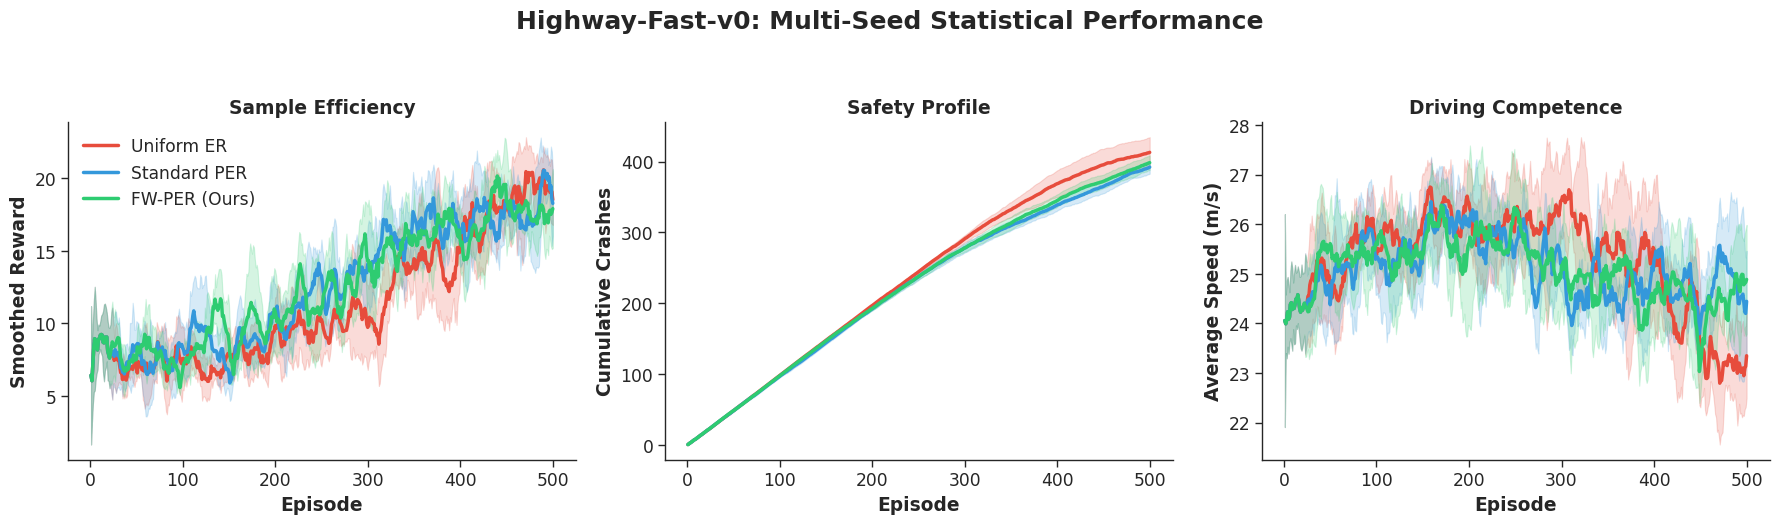

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

SAVE_DIR = '/content/drive/MyDrive/FW_PER_Research_Data/'
modes = {"uniform": "Uniform ER", "per": "Standard PER", "fw_per": "FW-PER (Ours)"}
seeds = [42, 123, 456, 789, 999]
colors = {"Uniform ER": "#e74c3c", "Standard PER": "#3498db", "FW-PER (Ours)": "#2ecc71"}

# Global Journal-Standard Formatting
plt.rcParams.update({
    "font.family": "serif",
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "legend.frameon": False
})

print("Aggregating 15 CSV files...")
all_data = []

for mode_key, mode_name in modes.items():
    for seed in seeds:
        filename = os.path.join(SAVE_DIR, f"highway_{mode_key}_seed_{seed}.csv")
        if os.path.exists(filename):
            df = pd.read_csv(filename)
            df['seed'] = seed
            df['Model'] = mode_name
            df['cumulative_crashes'] = df['crashed'].cumsum()
            df['smoothed_reward'] = df['reward'].rolling(window=10, min_periods=1).mean()
            df['smoothed_speed'] = df['avg_speed'].rolling(window=10, min_periods=1).mean()
            all_data.append(df)

final_df = pd.concat(all_data, ignore_index=True)

print("Generating Q2-Standard graphs...")
sns.set_style("ticks")
sns.set_context("paper", font_scale=1.4)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Highway-Fast-v0: Multi-Seed Statistical Performance", fontsize=18, fontweight='bold', y=1.05)

# Plot 1: Reward
sns.lineplot(data=final_df, x='episode', y='smoothed_reward', hue='Model', palette=colors, ax=axes[0], errorbar='sd', linewidth=2.5)
axes[0].set_title("Sample Efficiency", fontweight='bold')
axes[0].set_ylabel("Smoothed Reward", fontweight='bold')
axes[0].set_xlabel("Episode", fontweight='bold')
# Clean up legend
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles[0:], labels=labels[0:], title="", loc="upper left")

# Plot 2: Crashes
sns.lineplot(data=final_df, x='episode', y='cumulative_crashes', hue='Model', palette=colors, ax=axes[1], errorbar='sd', linewidth=2.5)
axes[1].set_title("Safety Profile", fontweight='bold')
axes[1].set_ylabel("Cumulative Crashes", fontweight='bold')
axes[1].set_xlabel("Episode", fontweight='bold')
axes[1].get_legend().remove() # Remove redundant legend

# Plot 3: Speed
sns.lineplot(data=final_df, x='episode', y='smoothed_speed', hue='Model', palette=colors, ax=axes[2], errorbar='sd', linewidth=2.5)
axes[2].set_title("Driving Competence", fontweight='bold')
axes[2].set_ylabel("Average Speed (m/s)", fontweight='bold')
axes[2].set_xlabel("Episode", fontweight='bold')
axes[2].get_legend().remove() # Remove redundant legend

sns.despine() # Removes top and right borders for a clean scientific look
plt.tight_layout()

# Save as PDF for vector graphics!
save_path = os.path.join(SAVE_DIR, "Highway_MultiSeed_Results.pdf")
plt.savefig(save_path, format='pdf', dpi=300, bbox_inches='tight')
print(f"Graph saved successfully to: {save_path}")
plt.show()

Aggregating 15 CSV files...
Generating Q2-Standard graphs with large text...
Graph saved successfully to: /content/drive/MyDrive/FW_PER_Research_Data/Highway_MultiSeed_Results_1.pdf


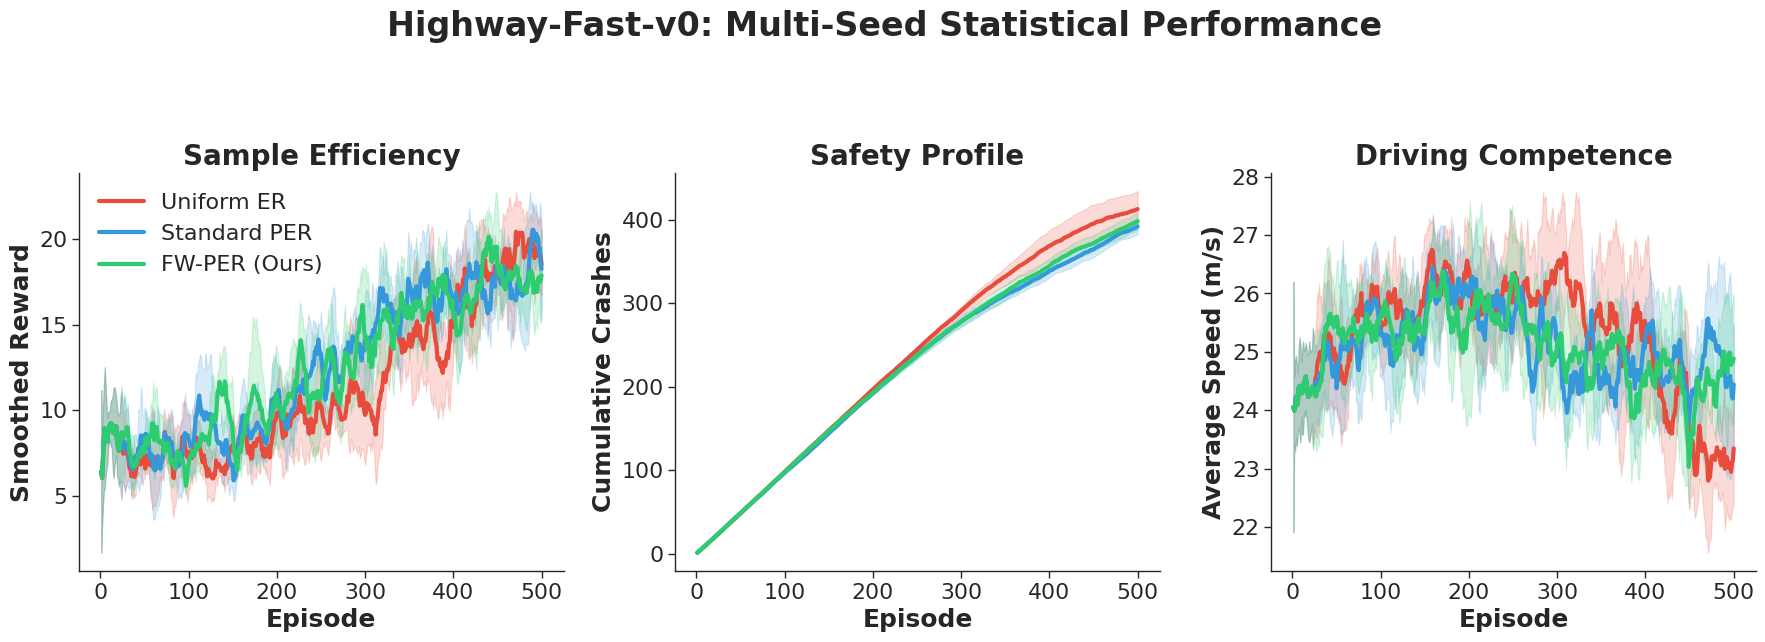

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

SAVE_DIR = '/content/drive/MyDrive/FW_PER_Research_Data/'
modes = {"uniform": "Uniform ER", "per": "Standard PER", "fw_per": "FW-PER (Ours)"}
seeds = [42, 123, 456, 789, 999]
colors = {"Uniform ER": "#e74c3c", "Standard PER": "#3498db", "FW-PER (Ours)": "#2ecc71"}

# GLOBALLY BOOSTED JOURNAL FORMATTING
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 16,               # Base font size
    "axes.titlesize": 20,          # Subplot title size
    "axes.labelsize": 18,          # X and Y axis label size
    "xtick.labelsize": 16,         # X axis tick numbers
    "ytick.labelsize": 16,         # Y axis tick numbers
    "legend.fontsize": 16,         # Legend text size
    "axes.linewidth": 2.0,         # Thicker borders to match bigger text
    "xtick.major.width": 2.0,
    "ytick.major.width": 2.0,
    "legend.frameon": False
})

print("Aggregating 15 CSV files...")
all_data = []

for mode_key, mode_name in modes.items():
    for seed in seeds:
        filename = os.path.join(SAVE_DIR, f"highway_{mode_key}_seed_{seed}.csv")
        if os.path.exists(filename):
            df = pd.read_csv(filename)
            df['seed'] = seed
            df['Model'] = mode_name
            df['cumulative_crashes'] = df['crashed'].cumsum()
            df['smoothed_reward'] = df['reward'].rolling(window=10, min_periods=1).mean()
            df['smoothed_speed'] = df['avg_speed'].rolling(window=10, min_periods=1).mean()
            all_data.append(df)

final_df = pd.concat(all_data, ignore_index=True)

print("Generating Q2-Standard graphs with large text...")
sns.set_style("ticks")
# Boosted the base Seaborn scale from 1.4 to 1.8
sns.set_context("paper", font_scale=1.8)

fig, axes = plt.subplots(1, 3, figsize=(18, 6)) # Slightly taller to fit big text
fig.suptitle("Highway-Fast-v0: Multi-Seed Statistical Performance", fontsize=24, fontweight='bold', y=1.08)

# Plot 1: Reward
sns.lineplot(data=final_df, x='episode', y='smoothed_reward', hue='Model', palette=colors, ax=axes[0], errorbar='sd', linewidth=3.0)
axes[0].set_title("Sample Efficiency", fontweight='bold', fontsize=20)
axes[0].set_ylabel("Smoothed Reward", fontweight='bold', fontsize=18)
axes[0].set_xlabel("Episode", fontweight='bold', fontsize=18)
handles, labels = axes[0].get_legend_handles_labels()
axes[0].legend(handles=handles[0:], labels=labels[0:], title="", loc="upper left", fontsize=16)

# Plot 2: Crashes
sns.lineplot(data=final_df, x='episode', y='cumulative_crashes', hue='Model', palette=colors, ax=axes[1], errorbar='sd', linewidth=3.0)
axes[1].set_title("Safety Profile", fontweight='bold', fontsize=20)
axes[1].set_ylabel("Cumulative Crashes", fontweight='bold', fontsize=18)
axes[1].set_xlabel("Episode", fontweight='bold', fontsize=18)
axes[1].get_legend().remove()

# Plot 3: Speed
sns.lineplot(data=final_df, x='episode', y='smoothed_speed', hue='Model', palette=colors, ax=axes[2], errorbar='sd', linewidth=3.0)
axes[2].set_title("Driving Competence", fontweight='bold', fontsize=20)
axes[2].set_ylabel("Average Speed (m/s)", fontweight='bold', fontsize=18)
axes[2].set_xlabel("Episode", fontweight='bold', fontsize=18)
axes[2].get_legend().remove()

sns.despine()
plt.tight_layout()

save_path = os.path.join(SAVE_DIR, "Highway_MultiSeed_Results_1.pdf")
plt.savefig(save_path, format='pdf', dpi=300, bbox_inches='tight')
print(f"Graph saved successfully to: {save_path}")
plt.show()

In [ ]:
!pip install swig
!pip install "gymnasium[box2d]"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 45.9 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import os
import traceback
from google.colab import drive

# ==========================================
# 1. SETUP & GOOGLE DRIVE
# ==========================================
drive.mount('/content/drive')
# Updated directory to keep LunarLander Noisy TV data completely separate
SAVE_DIR = '/content/drive/MyDrive/FW_PER_Research_Data_2/'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Data will be saved securely to: {SAVE_DIR}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# ==========================================
# 2. THE NOISY TV ENVIRONMENT WRAPPER
# ==========================================
class NoisyTVWrapper(gym.ObservationWrapper):
    """
    Simulates the 'Noisy TV' problem by permanently gluing
    pure, unlearnable aleatoric noise to the agent's observation state.
    """
    def __init__(self, env, noise_dim=10, noise_scale=5.0):
        super().__init__(env)
        self.noise_dim = noise_dim
        self.noise_scale = noise_scale

        old_space = env.observation_space
        new_low = np.append(old_space.low, np.full(noise_dim, -np.inf, dtype=np.float32))
        new_high = np.append(old_space.high, np.full(noise_dim, np.inf, dtype=np.float32))

        self.observation_space = gym.spaces.Box(low=new_low, high=new_high, dtype=np.float32)

    def observation(self, obs):
        noise = (np.random.randn(self.noise_dim) * self.noise_scale).astype(np.float32)
        return np.concatenate([obs, noise])

def make_noisy_lander():
    base_env = gym.make("LunarLander-v3")
    return NoisyTVWrapper(base_env, noise_dim=10)

# ==========================================
# 3. NEURAL NETWORKS & FW-PER BUFFER
# ==========================================
class QNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(obs_dim, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

class StateVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super(StateVAE, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)
        self.fc3 = nn.Linear(latent_dim, 64)
        self.fc4 = nn.Linear(64, input_dim)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar, z

class LatentDensityEstimator:
    def __init__(self, k=10, eta=1e-5):
        self.k = k
        self.eta = eta

    def compute_phi(self, z_batch, z_buffer=None):
        if z_buffer is None: z_buffer = z_batch
        distances = torch.cdist(z_batch, z_buffer, p=2.0)
        topk_dist, _ = torch.topk(distances, self.k + 1, largest=False, dim=1)
        knn_dist = topk_dist[:, 1:]
        rho = 1.0 / (knn_dist.mean(dim=1) + self.eta)
        phi = torch.log(1.0 + (1.0 / (rho + self.eta)))
        return phi

class FeatureWeightedReplayBuffer:
    def __init__(self, capacity, obs_dim, latent_dim, alpha=0.6, epsilon=1e-3):
        self.capacity = capacity
        self.alpha = alpha
        self.epsilon = epsilon
        self.ptr = 0
        self.size = 0

        self.states = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, 1), dtype=np.int64)
        self.rewards = np.zeros((capacity, 1), dtype=np.float32)
        self.next_states = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.dones = np.zeros((capacity, 1), dtype=np.float32)

        self.latents = np.zeros((capacity, latent_dim), dtype=np.float32)
        self.td_errors = np.zeros(capacity, dtype=np.float32)
        self.phi_scores = np.ones(capacity, dtype=np.float32)
        self.priorities = np.zeros(capacity, dtype=np.float32)

    def add(self, state, action, reward, next_state, done, latent_z):
        max_prio = self.priorities.max() if self.size > 0 else 1.0
        self.states[self.ptr] = state
        self.actions[self.ptr] = action
        self.rewards[self.ptr] = reward
        self.next_states[self.ptr] = next_state
        self.dones[self.ptr] = done
        self.latents[self.ptr] = latent_z

        self.priorities[self.ptr] = max_prio

        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def update_priorities(self, batch_indices, batch_td_errors):
        for i, idx in enumerate(batch_indices):
            self.td_errors[idx] = abs(batch_td_errors[i])
            self.priorities[idx] = (self.td_errors[idx] + self.epsilon) * self.phi_scores[idx]

    def update_semantic_rarity(self, density_estimator):
        if self.size < 100: return
        z_buffer = torch.FloatTensor(self.latents[:self.size]).to(device)
        with torch.no_grad():
            new_phis = density_estimator.compute_phi(z_buffer, z_buffer).cpu().numpy()
        self.phi_scores[:self.size] = new_phis
        self.priorities[:self.size] = (self.td_errors[:self.size] + self.epsilon) * self.phi_scores[:self.size]

    def sample(self, batch_size, beta=0.4):
        if self.size == 0: return None
        prios = self.priorities[:self.size]
        probs = prios ** self.alpha
        if probs.sum() == 0: return None
        probs /= probs.sum()

        indices = np.random.choice(self.size, batch_size, p=probs)
        total = self.size
        weights = (total * probs[indices]) ** (-beta)
        weights /= weights.max()

        batch = (
            torch.FloatTensor(self.states[indices]).to(device),
            torch.LongTensor(self.actions[indices]).to(device),
            torch.FloatTensor(self.rewards[indices]).to(device),
            torch.FloatTensor(self.next_states[indices]).to(device),
            torch.FloatTensor(self.dones[indices]).to(device),
            torch.FloatTensor(weights).to(device),
            indices
        )
        return batch

# ==========================================
# 4. FW-PER AGENT
# ==========================================
class FWPER_Agent:
    def __init__(self, obs_dim, action_dim, mode="fw_per"):
        self.action_dim = action_dim
        self.obs_dim = obs_dim
        self.mode = mode

        self.q_online = QNetwork(obs_dim, action_dim).to(device)
        self.q_target = QNetwork(obs_dim, action_dim).to(device)
        self.q_target.load_state_dict(self.q_online.state_dict())
        self.q_optimizer = torch.optim.Adam(self.q_online.parameters(), lr=5e-4)

        self.memory = FeatureWeightedReplayBuffer(capacity=15000, obs_dim=obs_dim, latent_dim=16)
        if self.mode == "uniform":
            self.memory.alpha = 0.0
        else:
            self.memory.alpha = 0.6

        self.vae = StateVAE(input_dim=obs_dim, latent_dim=16).to(device)
        self.vae_optimizer = torch.optim.Adam(self.vae.parameters(), lr=1e-3)
        self.density_estimator = LatentDensityEstimator(k=10)

    def act(self, state, epsilon=0.1):
        if np.random.rand() < epsilon: return np.random.randint(self.action_dim)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            return self.q_online(state_t).argmax().item()

    def train_q_network(self, batch_size=64, gamma=0.99):
        batch = self.memory.sample(batch_size)
        if batch is None: return
        states, actions, rewards, next_states, dones, weights, indices = batch
        with torch.no_grad():
            next_actions = self.q_online(next_states).argmax(1, keepdim=True)
            next_q = self.q_target(next_states).gather(1, next_actions)
            target_q = rewards + gamma * next_q * (1 - dones)
        current_q = self.q_online(states).gather(1, actions)
        td_errors = (target_q - current_q).squeeze().detach().cpu().numpy()
        self.memory.update_priorities(indices, td_errors)
        loss = (weights * F.mse_loss(current_q, target_q, reduction='none')).mean()
        self.q_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_online.parameters(), 1.0)
        self.q_optimizer.step()

    def train_vae(self, batch_size=128, beta=5.0):
        if self.memory.size < batch_size: return
        indices = np.random.choice(self.memory.size, batch_size)
        states = torch.FloatTensor(self.memory.states[indices]).to(device)
        self.vae_optimizer.zero_grad()
        recon, mu, logvar, _ = self.vae(states)
        recon_loss = F.mse_loss(recon, states, reduction='mean')
        kld_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + beta * kld_loss
        loss.backward()
        self.vae_optimizer.step()

# ==========================================
# 5. EXPERIMENT RUNNER
# ==========================================
def run_experiment(env_name="noisy_lander", experiment_mode="fw_per", max_episodes=500, seed=42):
    set_seed(seed)

    if env_name == "noisy_lander":
        env = make_noisy_lander()
    else:
        env = gym.make("LunarLander-v3") # Fallback just in case

    raw_obs, _ = env.reset(seed=seed)
    obs_dim = raw_obs.flatten().shape[0]
    action_dim = env.action_space.n

    agent = FWPER_Agent(obs_dim=obs_dim, action_dim=action_dim, mode=experiment_mode)

    # Custom logs for LunarLander
    logs = {"episode": [], "reward": [], "steps_survived": [], "solved": []}

    epsilon, epsilon_decay, epsilon_min = 1.0, 0.995, 0.05
    total_steps = 0

    for episode in range(1, max_episodes + 1):
        obs, _ = env.reset()
        obs = obs.flatten()
        ep_reward, steps_this_ep = 0, 0
        done = False

        while not done:
            total_steps += 1
            steps_this_ep += 1
            action = agent.act(obs, epsilon)
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            next_obs = next_obs.flatten()

            ep_reward += reward

            with torch.no_grad():
                obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
                _, _, _, latent_z = agent.vae(obs_t)
                latent_z = latent_z.squeeze().cpu().numpy()

            agent.memory.add(obs, action, reward, next_obs, done, latent_z)

            if agent.memory.size > 200: agent.train_q_network()
            if total_steps % 250 == 0 and experiment_mode == "fw_per": agent.train_vae()
            if total_steps % 1000 == 0:
                agent.q_target.load_state_dict(agent.q_online.state_dict())
                if experiment_mode == "fw_per": agent.memory.update_semantic_rarity(agent.density_estimator)

            obs = next_obs

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

        # LunarLander is typically considered "solved" if reward > 200
        solved = 1 if ep_reward >= 200 else 0

        logs["episode"].append(episode)
        logs["reward"].append(ep_reward)
        logs["steps_survived"].append(steps_this_ep)
        logs["solved"].append(solved)

        if episode % 50 == 0:
            print(f"   [Seed {seed}] Ep {episode:03d} | Reward: {ep_reward:7.1f} | Epsilon: {epsilon:.2f}")

    df = pd.DataFrame(logs)
    filename = os.path.join(SAVE_DIR, f"{env_name}_{experiment_mode}_seed_{seed}.csv")
    df.to_csv(filename, index=False)
    print(f"-> Saved: {filename}")
    return df

# ==========================================
# 6. MASTER EXECUTION LOOP
# ==========================================
if __name__ == "__main__":
    seeds = [42, 123, 456, 789, 999]
    modes = ["uniform", "per", "fw_per"]
    max_episodes = 500 # LunarLander usually converges within 500 episodes
    env_target = "noisy_lander"

    print("\n" + "="*50)
    print(f"STARTING EXPERIMENT: {env_target.upper()} (15 Total Runs)")
    print("="*50)

    for mode in modes:
        for seed in seeds:
            print(f"\n--- Running Mode: {mode.upper()} | Seed: {seed} ---")
            try:
                run_experiment(env_name=env_target, experiment_mode=mode, max_episodes=max_episodes, seed=seed)
            except Exception as e:
                print(f"!!! ERROR ON {mode} SEED {seed} !!!")
                print(traceback.format_exc())
                print("Continuing to next run...")

    print("\n" + "="*50)
    print("ALL NOISY TV EXPERIMENTS COMPLETED. DATA SAVED TO GOOGLE DRIVE.")
    print("="*50)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data will be saved securely to: /content/drive/MyDrive/FW_PER_Research_Data_2/

STARTING EXPERIMENT: NOISY_LANDER (15 Total Runs)

--- Running Mode: UNIFORM | Seed: 42 ---
   [Seed 42] Ep 050 | Reward:   -77.7 | Epsilon: 0.78
   [Seed 42] Ep 100 | Reward:  -123.5 | Epsilon: 0.61
   [Seed 42] Ep 150 | Reward:  -101.4 | Epsilon: 0.47
   [Seed 42] Ep 200 | Reward:  -118.4 | Epsilon: 0.37
   [Seed 42] Ep 250 | Reward:    -6.1 | Epsilon: 0.29
   [Seed 42] Ep 300 | Reward:   -18.8 | Epsilon: 0.22
   [Seed 42] Ep 350 | Reward:   -17.3 | Epsilon: 0.17
   [Seed 42] Ep 400 | Reward:  -226.8 | Epsilon: 0.13
   [Seed 42] Ep 450 | Reward:   -54.6 | Epsilon: 0.10
   [Seed 42] Ep 500 | Reward:    -5.9 | Epsilon: 0.08
-> Saved: /content/drive/MyDrive/FW_PER_Research_Data_2/noisy_lander_uniform_seed_42.csv

--- Running Mode: UNIFORM | Seed: 123 ---
   [Seed 123] Ep 050 | Rewa

Aggregating 15 Noisy TV CSV files...
Generating statistical graphs with Standard Deviation shading...
Graph saved successfully to: /content/drive/MyDrive/FW_PER_Research_Data_2/Noisy_TV_MultiSeed_Results.png


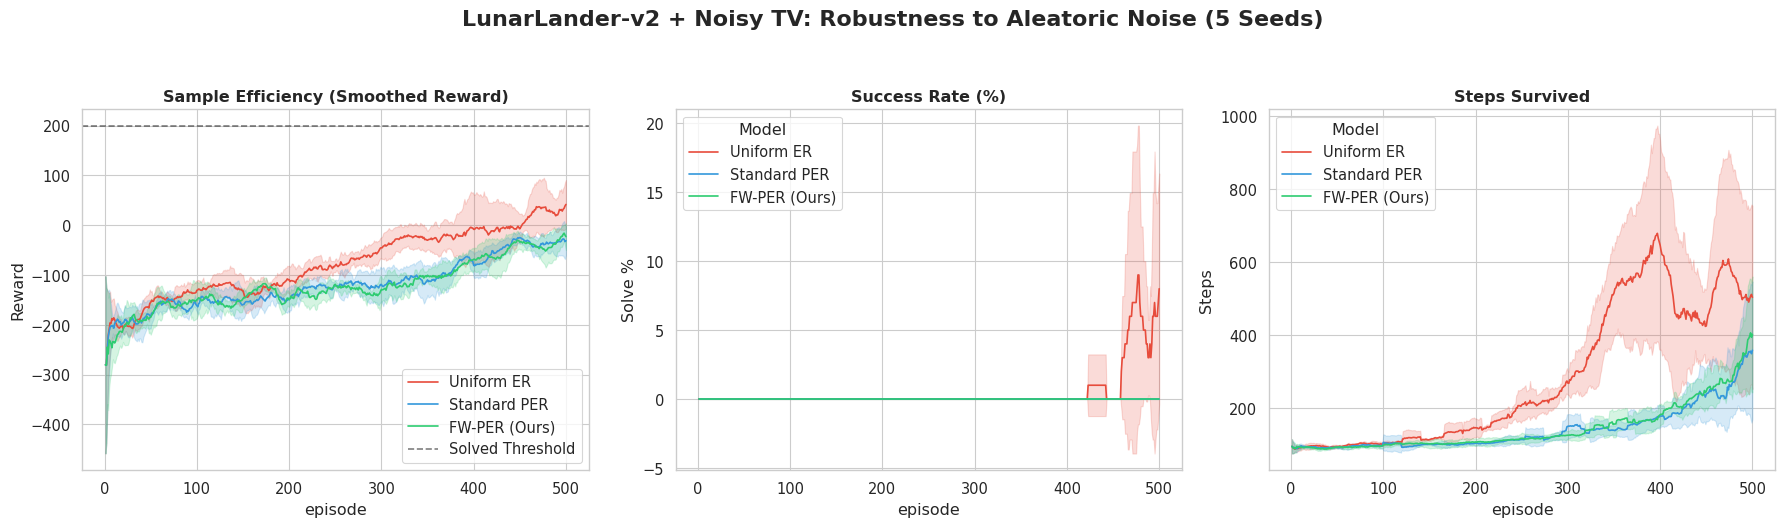

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

SAVE_DIR = '/content/drive/MyDrive/FW_PER_Research_Data_2/'
modes = {"uniform": "Uniform ER", "per": "Standard PER", "fw_per": "FW-PER (Ours)"}
seeds = [42, 123, 456, 789, 999]
colors = {"Uniform ER": "#e74c3c", "Standard PER": "#3498db", "FW-PER (Ours)": "#2ecc71"}

print("Aggregating 15 Noisy TV CSV files...")
all_data = []

# Load and aggregate all 15 runs
for mode_key, mode_name in modes.items():
    for seed in seeds:
        filename = os.path.join(SAVE_DIR, f"noisy_lander_{mode_key}_seed_{seed}.csv")
        if os.path.exists(filename):
            df = pd.read_csv(filename)
            df['seed'] = seed
            df['Model'] = mode_name

            # Apply a rolling window to smooth the incredibly noisy rewards
            df['smoothed_reward'] = df['reward'].rolling(window=20, min_periods=1).mean()
            # Calculate rolling success rate
            df['success_rate'] = df['solved'].rolling(window=20, min_periods=1).mean() * 100
            df['smoothed_steps'] = df['steps_survived'].rolling(window=20, min_periods=1).mean()

            all_data.append(df)
        else:
            print(f"Warning: {filename} not found.")

final_df = pd.concat(all_data, ignore_index=True)

# --- Plotting the Statistical Q1 Graphs ---
print("Generating statistical graphs with Standard Deviation shading...")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("LunarLander-v2 + Noisy TV: Robustness to Aleatoric Noise (5 Seeds)", fontsize=16, fontweight='bold', y=1.05)

# 1. Reward (Sample Efficiency)
sns.lineplot(data=final_df, x='episode', y='smoothed_reward', hue='Model', palette=colors, ax=axes[0], errorbar='sd')
axes[0].set_title("Sample Efficiency (Smoothed Reward)", fontweight='bold')
axes[0].set_ylabel("Reward")
axes[0].axhline(200, color='black', linestyle='--', alpha=0.5, label='Solved Threshold')
axes[0].legend()

# 2. Success Rate (% of episodes solved)
sns.lineplot(data=final_df, x='episode', y='success_rate', hue='Model', palette=colors, ax=axes[1], errorbar='sd')
axes[1].set_title("Success Rate (%)", fontweight='bold')
axes[1].set_ylabel("Solve %")

# 3. Steps Survived
sns.lineplot(data=final_df, x='episode', y='smoothed_steps', hue='Model', palette=colors, ax=axes[2], errorbar='sd')
axes[2].set_title("Steps Survived", fontweight='bold')
axes[2].set_ylabel("Steps")

plt.tight_layout()
save_path = os.path.join(SAVE_DIR, "Noisy_TV_MultiSeed_Results.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Graph saved successfully to: {save_path}")
plt.show()

In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import os
import traceback
from google.colab import drive

# ==========================================
# 1. SETUP & GOOGLE DRIVE
# ==========================================
drive.mount('/content/drive')
# Updated directory for the Fixed Noisy TV experiment
SAVE_DIR = '/content/drive/MyDrive/FW_PER_Research_Data_3/'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Data will be saved securely to: {SAVE_DIR}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# ==========================================
# 2. THE NOISY TV ENVIRONMENT WRAPPER
# ==========================================
class NoisyTVWrapper(gym.ObservationWrapper):
    def __init__(self, env, noise_dim=10, noise_scale=5.0):
        super().__init__(env)
        self.noise_dim = noise_dim
        self.noise_scale = noise_scale
        old_space = env.observation_space
        new_low = np.append(old_space.low, np.full(noise_dim, -np.inf, dtype=np.float32))
        new_high = np.append(old_space.high, np.full(noise_dim, np.inf, dtype=np.float32))
        self.observation_space = gym.spaces.Box(low=new_low, high=new_high, dtype=np.float32)

    def observation(self, obs):
        noise = (np.random.randn(self.noise_dim) * self.noise_scale).astype(np.float32)
        return np.concatenate([obs, noise])

def make_noisy_lander():
    base_env = gym.make("LunarLander-v3")
    return NoisyTVWrapper(base_env, noise_dim=10)

# ==========================================
# 3. NEURAL NETWORKS
# ==========================================
class QNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(obs_dim, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

class StateVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super(StateVAE, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)
        self.fc3 = nn.Linear(latent_dim, 64)
        self.fc4 = nn.Linear(64, input_dim)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar, z

class LatentDensityEstimator:
    def __init__(self, k=10, eta=1e-5):
        self.k = k
        self.eta = eta

    def compute_phi(self, z_batch, z_buffer=None):
        if z_buffer is None: z_buffer = z_batch
        distances = torch.cdist(z_batch, z_buffer, p=2.0)
        topk_dist, _ = torch.topk(distances, self.k + 1, largest=False, dim=1)
        knn_dist = topk_dist[:, 1:]
        rho = 1.0 / (knn_dist.mean(dim=1) + self.eta)
        phi = torch.log(1.0 + (1.0 / (rho + self.eta)))
        return phi

# ==========================================
# 4. FIXED FW-PER BUFFER (WITH NORMALIZATION)
# ==========================================
class FeatureWeightedReplayBuffer:
    def __init__(self, capacity, obs_dim, latent_dim, alpha=0.6, epsilon=1e-3):
        self.capacity = capacity
        self.alpha = alpha
        self.epsilon = epsilon
        self.ptr = 0
        self.size = 0

        self.states = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, 1), dtype=np.int64)
        self.rewards = np.zeros((capacity, 1), dtype=np.float32)
        self.next_states = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.dones = np.zeros((capacity, 1), dtype=np.float32)

        self.latents = np.zeros((capacity, latent_dim), dtype=np.float32)
        self.td_errors = np.zeros(capacity, dtype=np.float32)
        self.phi_scores = np.ones(capacity, dtype=np.float32)
        self.priorities = np.zeros(capacity, dtype=np.float32)

    def _recalculate_priorities(self):
        """THE Q1 FIX: Normalizes TD-Errors before multiplying by Phi"""
        if self.size == 0: return

        current_tds = self.td_errors[:self.size]
        td_min, td_max = current_tds.min(), current_tds.max()

        if td_max > td_min:
            norm_tds = (current_tds - td_min) / (td_max - td_min + 1e-8)
        else:
            norm_tds = np.zeros(self.size)

        # The new mathematically bounded equation
        self.priorities[:self.size] = (norm_tds + self.epsilon) * self.phi_scores[:self.size]

    def add(self, state, action, reward, next_state, done, latent_z):
        max_prio = self.priorities.max() if self.size > 0 else 1.0
        self.states[self.ptr] = state
        self.actions[self.ptr] = action
        self.rewards[self.ptr] = reward
        self.next_states[self.ptr] = next_state
        self.dones[self.ptr] = done
        self.latents[self.ptr] = latent_z
        self.priorities[self.ptr] = max_prio

        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def update_priorities(self, batch_indices, batch_td_errors):
        for i, idx in enumerate(batch_indices):
            self.td_errors[idx] = abs(batch_td_errors[i])
        self._recalculate_priorities()

    def update_semantic_rarity(self, density_estimator):
        if self.size < 100: return
        z_buffer = torch.FloatTensor(self.latents[:self.size]).to(device)
        with torch.no_grad():
            new_phis = density_estimator.compute_phi(z_buffer, z_buffer).cpu().numpy()
        self.phi_scores[:self.size] = new_phis
        self._recalculate_priorities()

    def sample(self, batch_size, beta=0.4):
        if self.size == 0: return None
        prios = self.priorities[:self.size]
        probs = prios ** self.alpha
        if probs.sum() == 0: return None
        probs /= probs.sum()

        indices = np.random.choice(self.size, batch_size, p=probs)
        total = self.size
        weights = (total * probs[indices]) ** (-beta)
        weights /= weights.max()

        batch = (
            torch.FloatTensor(self.states[indices]).to(device),
            torch.LongTensor(self.actions[indices]).to(device),
            torch.FloatTensor(self.rewards[indices]).to(device),
            torch.FloatTensor(self.next_states[indices]).to(device),
            torch.FloatTensor(self.dones[indices]).to(device),
            torch.FloatTensor(weights).to(device),
            indices
        )
        return batch

# ==========================================
# 5. FW-PER AGENT
# ==========================================
class FWPER_Agent:
    def __init__(self, obs_dim, action_dim, mode="fw_per"):
        self.action_dim = action_dim
        self.obs_dim = obs_dim
        self.mode = mode

        self.q_online = QNetwork(obs_dim, action_dim).to(device)
        self.q_target = QNetwork(obs_dim, action_dim).to(device)
        self.q_target.load_state_dict(self.q_online.state_dict())
        self.q_optimizer = torch.optim.Adam(self.q_online.parameters(), lr=5e-4)

        self.memory = FeatureWeightedReplayBuffer(capacity=15000, obs_dim=obs_dim, latent_dim=16)
        if self.mode == "uniform":
            self.memory.alpha = 0.0
        else:
            self.memory.alpha = 0.6

        self.vae = StateVAE(input_dim=obs_dim, latent_dim=16).to(device)
        self.vae_optimizer = torch.optim.Adam(self.vae.parameters(), lr=1e-3)
        self.density_estimator = LatentDensityEstimator(k=10)

    def act(self, state, epsilon=0.1):
        if np.random.rand() < epsilon: return np.random.randint(self.action_dim)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            return self.q_online(state_t).argmax().item()

    def train_q_network(self, batch_size=64, gamma=0.99):
        batch = self.memory.sample(batch_size)
        if batch is None: return
        states, actions, rewards, next_states, dones, weights, indices = batch
        with torch.no_grad():
            next_actions = self.q_online(next_states).argmax(1, keepdim=True)
            next_q = self.q_target(next_states).gather(1, next_actions)
            target_q = rewards + gamma * next_q * (1 - dones)
        current_q = self.q_online(states).gather(1, actions)
        td_errors = (target_q - current_q).squeeze().detach().cpu().numpy()
        self.memory.update_priorities(indices, td_errors)
        loss = (weights * F.mse_loss(current_q, target_q, reduction='none')).mean()
        self.q_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_online.parameters(), 1.0)
        self.q_optimizer.step()

    def train_vae(self, batch_size=128, beta=5.0):
        if self.memory.size < batch_size: return
        indices = np.random.choice(self.memory.size, batch_size)
        states = torch.FloatTensor(self.memory.states[indices]).to(device)
        self.vae_optimizer.zero_grad()
        recon, mu, logvar, _ = self.vae(states)
        recon_loss = F.mse_loss(recon, states, reduction='mean')
        kld_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + beta * kld_loss
        loss.backward()
        self.vae_optimizer.step()

# ==========================================
# 6. EXPERIMENT RUNNER
# ==========================================
def run_experiment(env_name="noisy_lander", experiment_mode="fw_per", max_episodes=500, seed=42):
    set_seed(seed)

    if env_name == "noisy_lander":
        env = make_noisy_lander()
    else:
        env = gym.make("LunarLander-v3")

    raw_obs, _ = env.reset(seed=seed)
    obs_dim = raw_obs.flatten().shape[0]
    action_dim = env.action_space.n

    agent = FWPER_Agent(obs_dim=obs_dim, action_dim=action_dim, mode=experiment_mode)

    logs = {"episode": [], "reward": [], "steps_survived": [], "solved": []}

    epsilon, epsilon_decay, epsilon_min = 1.0, 0.995, 0.05
    total_steps = 0

    for episode in range(1, max_episodes + 1):
        obs, _ = env.reset()
        obs = obs.flatten()
        ep_reward, steps_this_ep = 0, 0
        done = False

        while not done:
            total_steps += 1
            steps_this_ep += 1
            action = agent.act(obs, epsilon)
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            next_obs = next_obs.flatten()

            ep_reward += reward

            with torch.no_grad():
                obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
                _, _, _, latent_z = agent.vae(obs_t)
                latent_z = latent_z.squeeze().cpu().numpy()

            agent.memory.add(obs, action, reward, next_obs, done, latent_z)

            if agent.memory.size > 200: agent.train_q_network()
            if total_steps % 250 == 0 and experiment_mode == "fw_per": agent.train_vae()
            if total_steps % 1000 == 0:
                agent.q_target.load_state_dict(agent.q_online.state_dict())
                if experiment_mode == "fw_per": agent.memory.update_semantic_rarity(agent.density_estimator)

            obs = next_obs

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        solved = 1 if ep_reward >= 200 else 0

        logs["episode"].append(episode)
        logs["reward"].append(ep_reward)
        logs["steps_survived"].append(steps_this_ep)
        logs["solved"].append(solved)

        if episode % 50 == 0:
            print(f"   [Seed {seed}] Ep {episode:03d} | Reward: {ep_reward:7.1f} | Epsilon: {epsilon:.2f}")

    df = pd.DataFrame(logs)
    filename = os.path.join(SAVE_DIR, f"{env_name}_{experiment_mode}_seed_{seed}.csv")
    df.to_csv(filename, index=False)
    print(f"-> Saved: {filename}")
    return df

# ==========================================
# 7. MASTER EXECUTION LOOP
# ==========================================
if __name__ == "__main__":
    seeds = [42, 123, 456, 789, 999]
    modes = ["uniform", "per", "fw_per"]
    max_episodes = 500
    env_target = "noisy_lander"

    print("\n" + "="*50)
    print(f"STARTING 'FIXED' EXPERIMENT: {env_target.upper()} (15 Total Runs)")
    print("="*50)

    for mode in modes:
        for seed in seeds:
            print(f"\n--- Running Mode: {mode.upper()} | Seed: {seed} ---")
            try:
                run_experiment(env_name=env_target, experiment_mode=mode, max_episodes=max_episodes, seed=seed)
            except Exception as e:
                print(f"!!! ERROR ON {mode} SEED {seed} !!!")
                print(traceback.format_exc())
                print("Continuing to next run...")

    print("\n" + "="*50)
    print("ALL RUNS COMPLETED. MATH PATCH APPLIED SUCCESSFULLY.")
    print("="*50)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data will be saved securely to: /content/drive/MyDrive/FW_PER_Research_Data_3/

STARTING 'FIXED' EXPERIMENT: NOISY_LANDER (15 Total Runs)

--- Running Mode: UNIFORM | Seed: 42 ---
!!! ERROR ON uniform SEED 42 !!!
Traceback (most recent call last):
  File "/tmp/ipython-input-2656514408.py", line 337, in <cell line: 0>
    run_experiment(env_name=env_target, experiment_mode=mode, max_episodes=max_episodes, seed=seed)
  File "/tmp/ipython-input-2656514408.py", line 257, in run_experiment
    env = make_noisy_lander()
          ^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipython-input-2656514408.py", line 46, in make_noisy_lander
    base_env = gym.make("LunarLander-v2")
               ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py", line 681, in make
    env_spec = _find_spec(id)
               ^^^^^^^^^^^^^^
  Fil

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment LunarLander-v2 is out of date. You should consider upgrading to version `v3`.
  logger.deprecation(


In [ ]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import os
import traceback
import highway_env
from google.colab import drive

# ==========================================
# 1. SETUP & GOOGLE DRIVE
# ==========================================
drive.mount('/content/drive')
# Pointing back to your ORIGINAL folder to compare against your first runs
SAVE_DIR = '/content/drive/MyDrive/FW_PER_Research_Data_add/'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Data will be saved securely to: {SAVE_DIR}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# ==========================================
# 2. NEURAL NETWORKS
# ==========================================
class QNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(obs_dim, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

class StateVAE(nn.Module):
    def __init__(self, input_dim, latent_dim=16):
        super(StateVAE, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc_mu = nn.Linear(64, latent_dim)
        self.fc_logvar = nn.Linear(64, latent_dim)
        self.fc3 = nn.Linear(latent_dim, 64)
        self.fc4 = nn.Linear(64, input_dim)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.fc_mu(h1), self.fc_logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h3 = F.relu(self.fc3(z))
        return self.fc4(h3)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar, z

class LatentDensityEstimator:
    def __init__(self, k=10, eta=1e-5):
        self.k = k
        self.eta = eta

    def compute_phi(self, z_batch, z_buffer=None):
        if z_buffer is None: z_buffer = z_batch
        distances = torch.cdist(z_batch, z_buffer, p=2.0)
        topk_dist, _ = torch.topk(distances, self.k + 1, largest=False, dim=1)
        knn_dist = topk_dist[:, 1:]
        rho = 1.0 / (knn_dist.mean(dim=1) + self.eta)
        phi = torch.log(1.0 + (1.0 / (rho + self.eta)))
        return phi

# ==========================================
# 3. ADDITION FW-PER BUFFER (THE ABLATION)
# ==========================================
class AdditionFeatureWeightedReplayBuffer:
    def __init__(self, capacity, obs_dim, latent_dim, alpha=0.6, epsilon=1e-3):
        self.capacity = capacity
        self.alpha = alpha
        self.epsilon = epsilon
        self.ptr = 0
        self.size = 0

        self.states = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, 1), dtype=np.int64)
        self.rewards = np.zeros((capacity, 1), dtype=np.float32)
        self.next_states = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.dones = np.zeros((capacity, 1), dtype=np.float32)

        self.latents = np.zeros((capacity, latent_dim), dtype=np.float32)
        self.td_errors = np.zeros(capacity, dtype=np.float32)
        self.phi_scores = np.ones(capacity, dtype=np.float32)
        self.priorities = np.zeros(capacity, dtype=np.float32)

    def add(self, state, action, reward, next_state, done, latent_z):
        max_prio = self.priorities.max() if self.size > 0 else 1.0
        self.states[self.ptr] = state
        self.actions[self.ptr] = action
        self.rewards[self.ptr] = reward
        self.next_states[self.ptr] = next_state
        self.dones[self.ptr] = done
        self.latents[self.ptr] = latent_z
        self.priorities[self.ptr] = max_prio

        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def update_priorities(self, batch_indices, batch_td_errors):
        for i, idx in enumerate(batch_indices):
            self.td_errors[idx] = abs(batch_td_errors[i])
            # THE ABLATION: Using Addition (+) instead of Multiplication (*)
            self.priorities[idx] = (self.td_errors[idx] + self.epsilon) + self.phi_scores[idx]

    def update_semantic_rarity(self, density_estimator):
        if self.size < 100: return
        z_buffer = torch.FloatTensor(self.latents[:self.size]).to(device)
        with torch.no_grad():
            new_phis = density_estimator.compute_phi(z_buffer, z_buffer).cpu().numpy()
        self.phi_scores[:self.size] = new_phis
        # THE ABLATION: Using Addition (+) instead of Multiplication (*)
        self.priorities[:self.size] = (self.td_errors[:self.size] + self.epsilon) + self.phi_scores[:self.size]

    def sample(self, batch_size, beta=0.4):
        if self.size == 0: return None
        prios = self.priorities[:self.size]
        probs = prios ** self.alpha
        if probs.sum() == 0: return None
        probs /= probs.sum()

        indices = np.random.choice(self.size, batch_size, p=probs)
        total = self.size
        weights = (total * probs[indices]) ** (-beta)
        weights /= weights.max()

        batch = (
            torch.FloatTensor(self.states[indices]).to(device),
            torch.LongTensor(self.actions[indices]).to(device),
            torch.FloatTensor(self.rewards[indices]).to(device),
            torch.FloatTensor(self.next_states[indices]).to(device),
            torch.FloatTensor(self.dones[indices]).to(device),
            torch.FloatTensor(weights).to(device),
            indices
        )
        return batch

# ==========================================
# 4. FW-PER AGENT
# ==========================================
class FWPER_Agent:
    def __init__(self, obs_dim, action_dim):
        self.action_dim = action_dim
        self.obs_dim = obs_dim

        self.q_online = QNetwork(obs_dim, action_dim).to(device)
        self.q_target = QNetwork(obs_dim, action_dim).to(device)
        self.q_target.load_state_dict(self.q_online.state_dict())
        self.q_optimizer = torch.optim.Adam(self.q_online.parameters(), lr=5e-4)

        # Initializing the custom ADDITION buffer
        self.memory = AdditionFeatureWeightedReplayBuffer(capacity=15000, obs_dim=obs_dim, latent_dim=16)

        self.vae = StateVAE(input_dim=obs_dim, latent_dim=16).to(device)
        self.vae_optimizer = torch.optim.Adam(self.vae.parameters(), lr=1e-3)
        self.density_estimator = LatentDensityEstimator(k=10)

    def act(self, state, epsilon=0.1):
        if np.random.rand() < epsilon: return np.random.randint(self.action_dim)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            return self.q_online(state_t).argmax().item()

    def train_q_network(self, batch_size=64, gamma=0.99):
        batch = self.memory.sample(batch_size)
        if batch is None: return
        states, actions, rewards, next_states, dones, weights, indices = batch
        with torch.no_grad():
            next_actions = self.q_online(next_states).argmax(1, keepdim=True)
            next_q = self.q_target(next_states).gather(1, next_actions)
            target_q = rewards + gamma * next_q * (1 - dones)
        current_q = self.q_online(states).gather(1, actions)
        td_errors = (target_q - current_q).squeeze().detach().cpu().numpy()
        self.memory.update_priorities(indices, td_errors)
        loss = (weights * F.mse_loss(current_q, target_q, reduction='none')).mean()
        self.q_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_online.parameters(), 1.0)
        self.q_optimizer.step()

    def train_vae(self, batch_size=128, beta=5.0):
        if self.memory.size < batch_size: return
        indices = np.random.choice(self.memory.size, batch_size)
        states = torch.FloatTensor(self.memory.states[indices]).to(device)
        self.vae_optimizer.zero_grad()
        recon, mu, logvar, _ = self.vae(states)
        recon_loss = F.mse_loss(recon, states, reduction='mean')
        kld_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + beta * kld_loss
        loss.backward()
        self.vae_optimizer.step()

# ==========================================
# 5. EXPERIMENT RUNNER
# ==========================================
def run_experiment(env_name="highway-fast-v0", experiment_mode="fw_per_add", max_episodes=500, seed=42):
    set_seed(seed)
    env = gym.make(env_name)
    raw_obs, _ = env.reset(seed=seed)
    obs_dim = raw_obs.flatten().shape[0]
    action_dim = env.action_space.n

    agent = FWPER_Agent(obs_dim=obs_dim, action_dim=action_dim)

    logs = {"episode": [], "reward": [], "crashed": [], "avg_speed": [], "steps_survived": []}

    epsilon, epsilon_decay, epsilon_min = 1.0, 0.995, 0.05
    total_steps = 0

    for episode in range(1, max_episodes + 1):
        obs, _ = env.reset()
        obs = obs.flatten()
        ep_reward, ep_speeds, crashed, steps_this_ep = 0, [], False, 0
        done = False

        while not done:
            total_steps += 1
            steps_this_ep += 1
            action = agent.act(obs, epsilon)
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            next_obs = next_obs.flatten()

            ep_reward += reward
            ep_speeds.append(info.get('speed', 0))
            if info.get('crashed', False): crashed = True

            with torch.no_grad():
                obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
                _, _, _, latent_z = agent.vae(obs_t)
                latent_z = latent_z.squeeze().cpu().numpy()

            agent.memory.add(obs, action, reward, next_obs, done, latent_z)

            if agent.memory.size > 200: agent.train_q_network()
            if total_steps % 250 == 0: agent.train_vae()
            if total_steps % 1000 == 0:
                agent.q_target.load_state_dict(agent.q_online.state_dict())
                agent.memory.update_semantic_rarity(agent.density_estimator)

            obs = next_obs

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        logs["episode"].append(episode)
        logs["reward"].append(ep_reward)
        logs["crashed"].append(int(crashed))
        logs["avg_speed"].append(np.mean(ep_speeds) if ep_speeds else 0)
        logs["steps_survived"].append(steps_this_ep)

        if episode % 50 == 0:
            print(f"   [Seed {seed}] Ep {episode:03d} | Reward: {ep_reward:5.1f} | Epsilon: {epsilon:.2f}")

    df = pd.DataFrame(logs)
    filename = os.path.join(SAVE_DIR, f"highway_{experiment_mode}_seed_{seed}.csv")
    df.to_csv(filename, index=False)
    print(f"-> Saved: {filename}")
    return df

# ==========================================
# 6. MASTER EXECUTION LOOP
# ==========================================
if __name__ == "__main__":
    seeds = [42, 123, 456, 789, 999]
    mode = "fw_per_add"
    max_episodes = 500

    print("\n" + "="*50)
    print("STARTING MATHEMATICAL ABLATION (5 Runs)")
    print("="*50)

    for seed in seeds:
        print(f"\n--- Running Mode: {mode.upper()} | Seed: {seed} ---")
        try:
            run_experiment(experiment_mode=mode, max_episodes=max_episodes, seed=seed)
        except Exception as e:
            print(f"!!! ERROR ON {mode} SEED {seed} !!!")
            print(traceback.format_exc())
            print("Continuing to next run...")

    print("\n" + "="*50)
    print("ABLATION COMPLETED. DATASET IS 100% COMPLETE.")
    print("="*50)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data will be saved securely to: /content/drive/MyDrive/FW_PER_Research_Data_add/

STARTING MATHEMATICAL ABLATION (5 Runs)

--- Running Mode: FW_PER_ADD | Seed: 42 ---
   [Seed 42] Ep 050 | Reward:   2.0 | Epsilon: 0.78
   [Seed 42] Ep 100 | Reward:   5.0 | Epsilon: 0.61
   [Seed 42] Ep 150 | Reward:   4.4 | Epsilon: 0.47
   [Seed 42] Ep 200 | Reward:   5.1 | Epsilon: 0.37
   [Seed 42] Ep 250 | Reward:   5.9 | Epsilon: 0.29
   [Seed 42] Ep 300 | Reward:   7.6 | Epsilon: 0.22
   [Seed 42] Ep 350 | Reward:   6.7 | Epsilon: 0.17
   [Seed 42] Ep 400 | Reward:  22.4 | Epsilon: 0.13
   [Seed 42] Ep 450 | Reward:  11.1 | Epsilon: 0.10
   [Seed 42] Ep 500 | Reward:  23.2 | Epsilon: 0.08
-> Saved: /content/drive/MyDrive/FW_PER_Research_Data_add/highway_fw_per_add_seed_42.csv

--- Running Mode: FW_PER_ADD | Seed: 123 ---
   [Seed 123] Ep 050 | Reward:   4.6 | Epsilon: 0

Aggregating Ablation CSV files...
Generating Mathematical Ablation graphs...
Graph saved successfully to: /content/drive/MyDrive/FW_PER_Research_Data/Mathematical_Ablation_Results.png


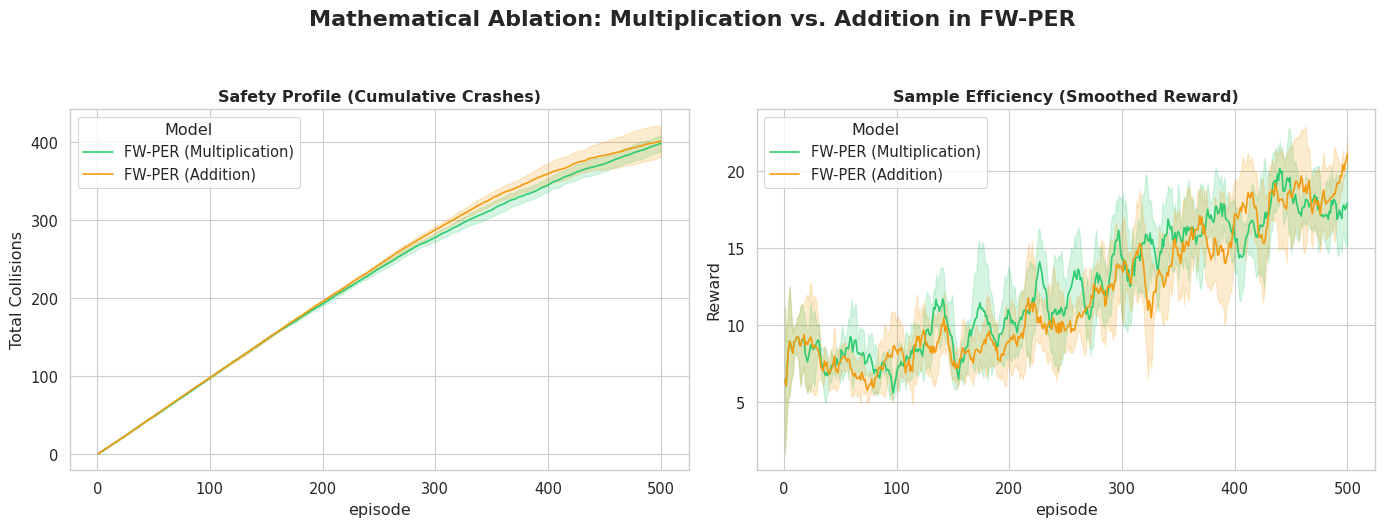

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

SAVE_DIR = '/content/drive/MyDrive/FW_PER_Research_Data/'
# We are only comparing our two mathematical variants
modes = {"fw_per": "FW-PER (Multiplication)", "fw_per_add": "FW-PER (Addition)"}
seeds = [42, 123, 456, 789, 999]
colors = {"FW-PER (Multiplication)": "#2ecc71", "FW-PER (Addition)": "#f39c12"}

print("Aggregating Ablation CSV files...")
all_data = []

for mode_key, mode_name in modes.items():
    for seed in seeds:
        filename = os.path.join(SAVE_DIR, f"highway_{mode_key}_seed_{seed}.csv")
        if os.path.exists(filename):
            df = pd.read_csv(filename)
            df['seed'] = seed
            df['Model'] = mode_name

            df['cumulative_crashes'] = df['crashed'].cumsum()
            df['smoothed_reward'] = df['reward'].rolling(window=10, min_periods=1).mean()

            all_data.append(df)
        else:
            print(f"Warning: {filename} not found.")

final_df = pd.concat(all_data, ignore_index=True)

# --- Plotting the Ablation Graph ---
print("Generating Mathematical Ablation graphs...")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Mathematical Ablation: Multiplication vs. Addition in FW-PER", fontsize=16, fontweight='bold', y=1.05)

# 1. Safety Profile (Cumulative Crashes) - The primary metric
sns.lineplot(data=final_df, x='episode', y='cumulative_crashes', hue='Model', palette=colors, ax=axes[0], errorbar='sd')
axes[0].set_title("Safety Profile (Cumulative Crashes)", fontweight='bold')
axes[0].set_ylabel("Total Collisions")

# 2. Sample Efficiency (Reward)
sns.lineplot(data=final_df, x='episode', y='smoothed_reward', hue='Model', palette=colors, ax=axes[1], errorbar='sd')
axes[1].set_title("Sample Efficiency (Smoothed Reward)", fontweight='bold')
axes[1].set_ylabel("Reward")

plt.tight_layout()
save_path = os.path.join(SAVE_DIR, "Mathematical_Ablation_Results.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Graph saved successfully to: {save_path}")
plt.show()

In [ ]:
import gymnasium as gym
from gymnasium.wrappers import NormalizeObservation
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import os
import traceback
from google.colab import drive

# ==========================================
# 1. SETUP & GOOGLE DRIVE
# ==========================================
drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/FW_PER_Research_Data_CURL/'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Data will be saved securely to: {SAVE_DIR}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# ==========================================
# 2. NORMALIZED NOISY TV WRAPPER
# ==========================================
class NoisyTVWrapper(gym.ObservationWrapper):
    def __init__(self, env, noise_dim=10, noise_scale=5.0):
        super().__init__(env)
        self.noise_dim = noise_dim
        self.noise_scale = noise_scale
        old_space = env.observation_space
        new_low = np.append(old_space.low, np.full(noise_dim, -np.inf, dtype=np.float32))
        new_high = np.append(old_space.high, np.full(noise_dim, np.inf, dtype=np.float32))
        self.observation_space = gym.spaces.Box(low=new_low, high=new_high, dtype=np.float32)

    def observation(self, obs):
        noise = (np.random.randn(self.noise_dim) * self.noise_scale).astype(np.float32)
        return np.concatenate([obs, noise])

def make_noisy_lander():
    base_env = gym.make("LunarLander-v3")
    noisy_env = NoisyTVWrapper(base_env, noise_dim=10)
    return NormalizeObservation(noisy_env)

# ==========================================
# 3. CONTRASTIVE NEURAL NETWORKS (THE Q1 PIVOT)
# ==========================================
class QNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super().__init__()
        self.fc1 = nn.Linear(obs_dim, 256)
        self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

class ContrastiveEncoder(nn.Module):
    """Encodes state down to a dense latent vector, dropping unpredictable noise."""
    def __init__(self, input_dim, latent_dim=4):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, latent_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        return self.fc2(x) # Linear output for latent space

class LatentDynamics(nn.Module):
    """Predicts z_{t+1} given z_t and action a_t."""
    def __init__(self, latent_dim, action_dim):
        super().__init__()
        self.action_emb = nn.Embedding(action_dim, 8)
        self.fc1 = nn.Linear(latent_dim + 8, 64)
        self.fc2 = nn.Linear(64, latent_dim)

    def forward(self, z, action):
        a_emb = self.action_emb(action)
        x = torch.cat([z, a_emb], dim=1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

class LatentDensityEstimator:
    def __init__(self, k=10, eta=1e-5):
        self.k = k
        self.eta = eta

    def compute_phi(self, z_batch, z_buffer=None):
        if z_buffer is None: z_buffer = z_batch
        distances = torch.cdist(z_batch, z_buffer, p=2.0)
        topk_dist, _ = torch.topk(distances, self.k + 1, largest=False, dim=1)
        knn_dist = topk_dist[:, 1:]
        rho = 1.0 / (knn_dist.mean(dim=1) + self.eta)
        phi = torch.log(1.0 + (1.0 / (rho + self.eta)))
        return phi

# ==========================================
# 4. FW-PER BUFFER (UNCHANGED MATH)
# ==========================================
class FeatureWeightedReplayBuffer:
    def __init__(self, capacity, obs_dim, latent_dim, alpha=0.6, epsilon=1e-3):
        self.capacity = capacity
        self.alpha = alpha
        self.epsilon = epsilon
        self.ptr = 0
        self.size = 0

        self.states = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, 1), dtype=np.int64)
        self.rewards = np.zeros((capacity, 1), dtype=np.float32)
        self.next_states = np.zeros((capacity, obs_dim), dtype=np.float32)
        self.dones = np.zeros((capacity, 1), dtype=np.float32)

        self.latents = np.zeros((capacity, latent_dim), dtype=np.float32)
        self.td_errors = np.zeros(capacity, dtype=np.float32)
        self.phi_scores = np.ones(capacity, dtype=np.float32)
        self.priorities = np.zeros(capacity, dtype=np.float32)

    def _recalculate_priorities(self):
        if self.size == 0: return
        current_tds = self.td_errors[:self.size]
        td_min, td_max = current_tds.min(), current_tds.max()
        if td_max > td_min:
            norm_tds = (current_tds - td_min) / (td_max - td_min + 1e-8)
        else:
            norm_tds = np.zeros(self.size)
        self.priorities[:self.size] = (norm_tds + self.epsilon) * self.phi_scores[:self.size]

    def add(self, state, action, reward, next_state, done, latent_z):
        max_prio = self.priorities.max() if self.size > 0 else 1.0
        self.states[self.ptr] = state
        self.actions[self.ptr] = action
        self.rewards[self.ptr] = reward
        self.next_states[self.ptr] = next_state
        self.dones[self.ptr] = done
        self.latents[self.ptr] = latent_z
        self.priorities[self.ptr] = max_prio

        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def update_priorities(self, batch_indices, batch_td_errors):
        for i, idx in enumerate(batch_indices):
            self.td_errors[idx] = abs(batch_td_errors[i])
        self._recalculate_priorities()

    def update_semantic_rarity(self, density_estimator):
        if self.size < 100: return
        z_buffer = torch.FloatTensor(self.latents[:self.size]).to(device)
        with torch.no_grad():
            new_phis = density_estimator.compute_phi(z_buffer, z_buffer).cpu().numpy()
        self.phi_scores[:self.size] = new_phis
        self._recalculate_priorities()

    def sample(self, batch_size, beta=0.4):
        if self.size == 0: return None
        prios = self.priorities[:self.size]
        probs = prios ** self.alpha
        if probs.sum() == 0: return None
        probs /= probs.sum()
        indices = np.random.choice(self.size, batch_size, p=probs)
        weights = (self.size * probs[indices]) ** (-beta)
        weights /= weights.max()

        batch = (
            torch.FloatTensor(self.states[indices]).to(device),
            torch.LongTensor(self.actions[indices]).to(device),
            torch.FloatTensor(self.rewards[indices]).to(device),
            torch.FloatTensor(self.next_states[indices]).to(device),
            torch.FloatTensor(self.dones[indices]).to(device),
            torch.FloatTensor(weights).to(device),
            indices
        )
        return batch

# ==========================================
# 5. CONTRASTIVE FW-PER AGENT
# ==========================================
class FWPER_Agent:
    def __init__(self, obs_dim, action_dim, mode="fw_per"):
        self.action_dim = action_dim
        self.obs_dim = obs_dim
        self.mode = mode

        # DQN Networks
        self.q_online = QNetwork(obs_dim, action_dim).to(device)
        self.q_target = QNetwork(obs_dim, action_dim).to(device)
        self.q_target.load_state_dict(self.q_online.state_dict())
        self.q_optimizer = torch.optim.Adam(self.q_online.parameters(), lr=5e-4)

        self.memory = FeatureWeightedReplayBuffer(capacity=15000, obs_dim=obs_dim, latent_dim=4)
        self.memory.alpha = 0.0 if self.mode == "uniform" else 0.6

        # The New Contrastive Brain
        self.encoder = ContrastiveEncoder(input_dim=obs_dim, latent_dim=4).to(device)
        self.dynamics = LatentDynamics(latent_dim=4, action_dim=action_dim).to(device)

        # Optimize them together
        self.contrastive_optimizer = torch.optim.Adam(
            list(self.encoder.parameters()) + list(self.dynamics.parameters()), lr=1e-3
        )
        self.density_estimator = LatentDensityEstimator(k=10)

    def act(self, state, epsilon=0.1):
        if np.random.rand() < epsilon: return np.random.randint(self.action_dim)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            return self.q_online(state_t).argmax().item()

    def train_q_network(self, batch_size=64, gamma=0.99):
        batch = self.memory.sample(batch_size)
        if batch is None: return
        states, actions, rewards, next_states, dones, weights, indices = batch
        with torch.no_grad():
            next_actions = self.q_online(next_states).argmax(1, keepdim=True)
            next_q = self.q_target(next_states).gather(1, next_actions)
            target_q = rewards + gamma * next_q * (1 - dones)
        current_q = self.q_online(states).gather(1, actions)
        td_errors = (target_q - current_q).squeeze().detach().cpu().numpy()
        self.memory.update_priorities(indices, td_errors)
        loss = (weights * F.mse_loss(current_q, target_q, reduction='none')).mean()
        self.q_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_online.parameters(), 1.0)
        self.q_optimizer.step()

    def train_contrastive(self, batch_size=128, temperature=0.1):
        """THE Q1 INFONCE LOSS: Forces the network to ignore unpredictable noise."""
        if self.memory.size < batch_size: return

        # Sample uniformly to avoid bias in representation learning
        indices = np.random.choice(self.memory.size, batch_size)
        states = torch.FloatTensor(self.memory.states[indices]).to(device)
        actions = torch.LongTensor(self.memory.actions[indices]).to(device).squeeze(-1)
        next_states = torch.FloatTensor(self.memory.next_states[indices]).to(device)

        # 1. Encode current and true next state
        z = self.encoder(states)
        z_next_true = self.encoder(next_states)

        # 2. Predict next state from z and action
        z_next_pred = self.dynamics(z, actions)

        # 3. Normalize vectors for Cosine Similarity
        z_next_pred = F.normalize(z_next_pred, p=2, dim=1)
        z_next_true = F.normalize(z_next_true, p=2, dim=1)

        # 4. InfoNCE Loss (Maximize similarity with true next state, minimize with batch)
        logits = torch.matmul(z_next_pred, z_next_true.T) / temperature
        labels = torch.arange(batch_size).to(device)

        loss = F.cross_entropy(logits, labels)

        self.contrastive_optimizer.zero_grad()
        loss.backward()
        self.contrastive_optimizer.step()

# ==========================================
# 6. EXPERIMENT RUNNER
# ==========================================
def run_experiment(env_name="noisy_lander", experiment_mode="fw_per", max_episodes=500, seed=42):
    set_seed(seed)

    if env_name == "noisy_lander":
        env = make_noisy_lander()
    else:
        env = NormalizeObservation(gym.make("LunarLander-v3"))

    raw_obs, _ = env.reset(seed=seed)
    obs_dim = raw_obs.flatten().shape[0]
    action_dim = env.action_space.n

    agent = FWPER_Agent(obs_dim=obs_dim, action_dim=action_dim, mode=experiment_mode)

    logs = {"episode": [], "reward": [], "steps_survived": [], "solved": []}

    epsilon, epsilon_decay, epsilon_min = 1.0, 0.995, 0.05
    total_steps = 0

    for episode in range(1, max_episodes + 1):
        obs, _ = env.reset()
        obs = obs.flatten()
        ep_reward, steps_this_ep = 0, 0
        done = False

        while not done:
            total_steps += 1
            steps_this_ep += 1
            action = agent.act(obs, epsilon)
            next_obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            next_obs = next_obs.flatten()

            ep_reward += reward

            with torch.no_grad():
                obs_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
                latent_z = agent.encoder(obs_t).squeeze().cpu().numpy()

            agent.memory.add(obs, action, reward, next_obs, done, latent_z)

            if agent.memory.size > 200: agent.train_q_network()
            # Train contrastive network instead of VAE
            if total_steps % 250 == 0 and experiment_mode == "fw_per": agent.train_contrastive()
            if total_steps % 1000 == 0:
                agent.q_target.load_state_dict(agent.q_online.state_dict())
                if experiment_mode == "fw_per": agent.memory.update_semantic_rarity(agent.density_estimator)

            obs = next_obs

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        solved = 1 if ep_reward >= 200 else 0

        logs["episode"].append(episode)
        logs["reward"].append(ep_reward)
        logs["steps_survived"].append(steps_this_ep)
        logs["solved"].append(solved)

        if episode % 50 == 0:
            print(f"   [Seed {seed}] Ep {episode:03d} | Reward: {ep_reward:7.1f} | Epsilon: {epsilon:.2f}")

    df = pd.DataFrame(logs)
    filename = os.path.join(SAVE_DIR, f"{env_name}_{experiment_mode}_seed_{seed}.csv")
    df.to_csv(filename, index=False)
    print(f"-> Saved: {filename}")
    return df

# ==========================================
# 7. MASTER EXECUTION LOOP
# ==========================================
if __name__ == "__main__":
    seeds = [42, 123, 456, 789, 999]
    modes = ["uniform", "per", "fw_per"]
    max_episodes = 500
    env_target = "noisy_lander"

    print("\n" + "="*50)
    print(f"STARTING 'CONTRASTIVE' EXPERIMENT: {env_target.upper()} (15 Total Runs)")
    print("="*50)

    for mode in modes:
        for seed in seeds:
            print(f"\n--- Running Mode: {mode.upper()} | Seed: {seed} ---")
            try:
                run_experiment(env_name=env_target, experiment_mode=mode, max_episodes=max_episodes, seed=seed)
            except Exception as e:
                print(f"!!! ERROR ON {mode} SEED {seed} !!!")
                print(traceback.format_exc())
                print("Continuing to next run...")

    print("\n" + "="*50)
    print("ALL RUNS COMPLETED. CONTRASTIVE BYPASS APPLIED SUCCESSFULLY.")
    print("="*50)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data will be saved securely to: /content/drive/MyDrive/FW_PER_Research_Data_CURL/

STARTING 'CONTRASTIVE' EXPERIMENT: NOISY_LANDER (15 Total Runs)

--- Running Mode: UNIFORM | Seed: 42 ---
   [Seed 42] Ep 050 | Reward:  -183.1 | Epsilon: 0.78
   [Seed 42] Ep 100 | Reward:   -44.0 | Epsilon: 0.61
   [Seed 42] Ep 150 | Reward:   -53.6 | Epsilon: 0.47
   [Seed 42] Ep 200 | Reward:    46.0 | Epsilon: 0.37
   [Seed 42] Ep 250 | Reward:   -53.1 | Epsilon: 0.29
   [Seed 42] Ep 300 | Reward:    16.8 | Epsilon: 0.22
   [Seed 42] Ep 350 | Reward:     6.1 | Epsilon: 0.17
   [Seed 42] Ep 400 | Reward:   136.6 | Epsilon: 0.13
   [Seed 42] Ep 450 | Reward:   -12.5 | Epsilon: 0.10
   [Seed 42] Ep 500 | Reward:   -80.2 | Epsilon: 0.08
-> Saved: /content/drive/MyDrive/FW_PER_Research_Data_CURL/noisy_lander_uniform_seed_42.csv

--- Running Mode: UNIFORM | Seed: 123 ---
   [See